# Ampere Analysis — End-to-End Comparison Notebook

Measures the **analysis** half of two OTF2 pipelines and adds it to the already-measured
**conversion** half, to compare the *whole* workflow:

| Pipeline | Conversion (already measured) | Analysis (measured here) |
|---|---|---|
| **fastotf2 + arkouda** | `run_20260717_203803_save/timings` (`totalTime`) | Ampere, `arkouda` backend, on a Slurm-launched arkouda server |
| **python + pandas** | `run_20260717_203326_save/timings` (`seconds`) | Ampere, `pandas` backend, single node |

**Why both backends read the *fastotf2* Parquet.** The Ampere analysis for *both* pipelines
loads the fastotf2-converted Parquet in `run_20260717_203803_save/pq/`. The Parquet content is
identical regardless of which converter produced it, so using the same bytes makes the
analysis-time comparison apples-to-apples (only the backend differs). The Python converter's
*output* is never used as analysis input — the Python pipeline contributes only its
already-measured *conversion time*. (This also avoids regenerating the very expensive Python
Parquet — the 32 GiB trace alone took ~3.75 h.) See `README-ampere-workflows-new.md`.

**This notebook does not re-run any conversion.** It only launches the Ampere analyses and
looks up the conversion timings.

**Layout** (mirrors `converter-scaling-new.ipynb`):
1. §0 Setup — `SYSTEM` switch, secrets, timestamped run folder.
2. §1 Environment — ampere / arkouda client / container / e4s-cl profile (arkouda side only).
3. §2 Design — configurable matrix; `DRY_RUN`/`SAMPLE_RUN`; writes `plan.json`.
4. §3 Collect — arkouda analyses (live) + pandas analyses (batch); timing CSVs.
5. §4 Combine — join analysis + conversion times into one tidy CSV.
6. §5 Analyse — plotnine graphs (self-contained via `ANALYZE_RUN`).

**The analysis logic (topology, metric config, `attribute` call) is ported from the original
`ampere-workflow.ipynb`, which is left unchanged.**


# 0. Environment & configuration

`SYSTEM` picks the cluster (`"other-ex"` or `"frontier"`); everything system-specific lives in
`SYSTEM_CONFIGS` (apptainer paths, arkouda container, cpus-per-task, the input run folders,
and `sbatch` extras). The Slurm **account** / **mail** are secrets — put them in a gitignored
`local_secrets.py` next to this notebook (see `local_secrets.example.py`), never hardcode.

Each execution of the config cell starts a fresh **timestamped run folder** under `out/`, so
runs never clobber each other. To *analyse a previous run* without collecting new data, skip
to §5 and set `ANALYZE_RUN`.


In [1]:
# --- Imports ---
import os
import re
import json
import glob
import time
import subprocess
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
from plotnine import *  # noqa: F401,F403

import workflows

# --- Which system are we running on? ---------------------------------------
# One line switches clusters; everything system-specific is in SYSTEM_CONFIGS below.
SYSTEM = "other-ex"   # "other-ex" | "frontier"

# --- Secrets (never hardcode) ----------------------------------------------
# Preferred: a gitignored local_secrets.py next to this notebook (env vars exported in a shell
# are NOT inherited by an already-running Jupyter kernel). Falls back to env vars.
try:
    from local_secrets import SLURM_ACCOUNT, SLURM_MAIL_USER
except ImportError:
    SLURM_ACCOUNT   = os.environ.get("SLURM_ACCOUNT")
    SLURM_MAIL_USER = os.environ.get("SLURM_MAIL_USER")


def _mail_sbatch_args():
    return (["--mail-type=BEGIN,END,FAIL", f"--mail-user={SLURM_MAIL_USER}"]
            if SLURM_MAIL_USER else [])


def _account_sbatch_args():
    return [f"--account={SLURM_ACCOUNT}"] if SLURM_ACCOUNT else []


# --- Per-system configuration ------------------------------------------------
# go_dir / apptainer_bin_path / apptainer_cache_dir: set to None when a system already has
# apptainer on PATH. fastotf2_run / python_run point at the ALREADY-COLLECTED conversion runs
# (this notebook reads their timings + fastotf2 Parquet; it never re-runs conversion).
_HERE = Path.cwd()   # the workflows/scaling directory

SYSTEM_CONFIGS = {
    "other-ex": {
        "arkouda_cpus_per_task": 64,
        "go_dir":              "/lus/scratch/crickett/go/",
        "apptainer_bin_path":  "/lus/scratch/crickett/software/usr/bin",
        "apptainer_cache_dir": "/lus/bnchlu1/khandeka/.local/apptainer/",
        "arkouda_container":   "docker://arezaiihpe/chapel-2.9.0-arkouda-2026.07.15-cxi:2.3.1",
        "sbatch_extra_args":   [],
        "ranks_per_node":      8,
        # Already-collected conversion runs (inputs; not modified):
        "fastotf2_run": str(_HERE / "out" / "run_20260717_203803_save"),
        # Small traces (2,4,8) were converted in a separate run; the primary run holds the rest.
        "fastotf2_run_extra": str(_HERE / "out" / "run_20260714_043638_save"),
        "python_run":   "/lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2-bench/out/run_20260717_203326_save",
    },
    "frontier": {
        # Structure mirrors other-ex; fill the paths in once the same runs exist on Frontier.
        "arkouda_cpus_per_task": 56,
        "go_dir":              None,
        "apptainer_bin_path":  None,
        "apptainer_cache_dir": None,
        "arkouda_container":   "docker://arezaiihpe/chapel-2.9.0-arkouda-2026.07.15-cxi:2.3.1",
        "sbatch_extra_args":   _account_sbatch_args() + _mail_sbatch_args(),
        "ranks_per_node":      8,
        "fastotf2_run": None,   # TODO: set to the Frontier fastotf2 conversion run folder
        "fastotf2_run_extra": None,  # TODO: optional 2nd run holding small traces (2,4,8)
        "python_run":   None,   # TODO: set to the Frontier python conversion run folder
    },
}

_cfg = SYSTEM_CONFIGS[SYSTEM]
if SYSTEM == "frontier" and not (SLURM_ACCOUNT and SLURM_MAIL_USER):
    raise RuntimeError(
        "SYSTEM='frontier' needs SLURM_ACCOUNT and SLURM_MAIL_USER -- create a gitignored "
        "local_secrets.py with those two variables, or set them as env vars before the "
        "Jupyter server process itself is started."
    )
if _cfg["fastotf2_run"] is None or _cfg["python_run"] is None:
    raise RuntimeError(f"SYSTEM='{SYSTEM}' has no fastotf2_run/python_run configured yet.")

go_dir                = _cfg["go_dir"]
apptainer_bin_path    = _cfg["apptainer_bin_path"]
apptainer_cache_dir   = _cfg["apptainer_cache_dir"]
ARKOUDA_CONTAINER     = _cfg["arkouda_container"]
ARKOUDA_CPUS          = _cfg["arkouda_cpus_per_task"]
RANKS_PER_NODE        = _cfg["ranks_per_node"]
SBATCH_EXTRA_ARGS     = _cfg["sbatch_extra_args"]
FASTOTF2_RUN          = Path(_cfg["fastotf2_run"])
PYTHON_RUN            = Path(_cfg["python_run"])

# Some traces live in a SECOND fastotf2 run (possibly with different nl/trial dir naming).
# canonical_pq_dir() and the conversion-time lookups search these runs in order and tolerate a
# trailing "_trial<N>" on pq/timings dir names (content is identical per size, per the converter).
_FASTOTF2_RUN_EXTRA   = _cfg.get("fastotf2_run_extra")
FASTOTF2_RUNS         = [FASTOTF2_RUN] + ([Path(_FASTOTF2_RUN_EXTRA)] if _FASTOTF2_RUN_EXTRA else [])


def _pq_variants(run_dir, traced_nodes):
    """(nl, trial, path) for every pq dir of a trace in a run; tolerates optional _trial<N>."""
    out = []
    for d in (run_dir / "pq").glob(f"size{traced_nodes}_nl*"):
        m = re.match(rf"size{traced_nodes}_nl(\d+)(?:_trial(\d+))?$", d.name)
        if m:
            out.append((int(m.group(1)), int(m.group(2) or 0), d))
    return sorted(out)


def fastotf2_run_for(traced_nodes):
    """First configured fastotf2 run that actually holds this trace's Parquet."""
    for r in FASTOTF2_RUNS:
        if _pq_variants(r, traced_nodes):
            return r
    raise FileNotFoundError(f"No fastotf2 pq dir for trace {traced_nodes} in {FASTOTF2_RUNS}")


def canonical_pq_dir(traced_nodes):
    """Canonical fastotf2 Parquet dir for a trace (content is nl/trial-independent -> pick the
    smallest nl, then smallest trial)."""
    return _pq_variants(fastotf2_run_for(traced_nodes), traced_nodes)[0][2]


def fastotf2_extra_pq_binds():
    """Canonical pq dirs for traces served by a NON-primary run, so the arkouda container can
    bind-mount them explicitly (the primary run's whole pq tree is already bound)."""
    binds = []
    for r in FASTOTF2_RUNS[1:]:
        for d in (r / "pq").glob("size*_nl*"):
            m = re.match(r"size(\d+)_nl\d+(?:_trial\d+)?$", d.name)
            if m:
                t = int(m.group(1))
                if fastotf2_run_for(t) == r:      # only traces the primary run doesn't have
                    cd = canonical_pq_dir(t)
                    if cd not in binds:
                        binds.append(cd)
    return binds

# Ampere analysis knobs (reused verbatim from the original ampere-workflow.ipynb).
METRIC   = "A2rocm_smi:::energy_count:device=6"
STRATEGY = "exclusive"

WORKFLOW_DIR = _HERE
CONTAINER_PATH = str(WORKFLOW_DIR / "chapel-arkouda.sif")

# --- Run folder & logging ---
RUN_TAG = f"run_{datetime.now():%Y%m%d_%H%M%S}"
RUN_DIR         = WORKFLOW_DIR / "out" / RUN_TAG
TIMINGS_DIR     = RUN_DIR / "timings"       # per-config analysis timing CSVs
SLURM_LOG_DIR   = RUN_DIR / "slurm_logs"    # pandas batch job + arkouda server logs
RUN_LOG_DIR     = RUN_DIR / "run_logs"      # sbatch scripts, driver, run_args
PLOTS_DIR       = RUN_DIR / "plots"
for d in (RUN_DIR, TIMINGS_DIR, SLURM_LOG_DIR, RUN_LOG_DIR, PLOTS_DIR):
    d.mkdir(parents=True, exist_ok=True)

workflows.set_workflow_log(str(RUN_DIR / "workflow.log"))  # note: this chdir's to RUN_DIR ...
os.chdir(WORKFLOW_DIR)                                      # ... so restore the workflow dir

print(f"SYSTEM       : {SYSTEM}")
print(f"RUN_TAG      : {RUN_TAG}")
print(f"RUN_DIR      : {RUN_DIR}")
print(f"fastotf2_run : {FASTOTF2_RUN}")
print(f"python_run   : {PYTHON_RUN}")
print(f"metric={METRIC}  strategy={STRATEGY}  ranks/node={RANKS_PER_NODE}")


No user workflows file found at ~/.workflows.py, skipping.
SYSTEM       : other-ex
RUN_TAG      : run_20260721_013234
RUN_DIR      : /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2/workflows/scaling/out/run_20260721_013234
fastotf2_run : /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2/workflows/scaling/out/run_20260717_203803_save
python_run   : /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2-bench/out/run_20260717_203326_save
metric=A2rocm_smi:::energy_count:device=6  strategy=exclusive  ranks/node=8


# 1. Environment — Ampere, arkouda client, container & e4s-cl profile

Prepares everything the **arkouda** analysis side needs. The **pandas** side needs none of
this (it is a pure Python library run in this kernel's venv).

> **Prerequisite (do this ONCE, by hand):** the e4s-cl venv must already exist and this
> notebook must run from its kernel. Create it with
> `cd e4s-cl-setup && ./setup_all.sh` — and if a `.venv` already exists, answer **`N`** to
> *"Recreate it?"* so your Python version/packages are preserved. **This notebook never runs
> `setup_all.sh` itself**, because its first step recreates the venv (picking whatever
> `python3.X` is first on PATH) and would wipe your installed packages — that is exactly the
> accident this section is written to avoid.

- **Ampere** must be importable (installed editable into the e4s-cl venv). `set_backend` is
  called explicitly per run (arkouda vs pandas), not left to the auto-default.
- **e4s-cl profile** `arkouda-container` is created/selected here (profile + host libraries
  only — never the venv), binding host paths and pointing at the container.
- **chapel-arkouda** container `.sif` is pulled once.
- **arkouda client** library must be importable so `set_backend('arkouda')` + `connect()` work.

Cells are idempotent — safe to re-run; they skip work already done. Set `SETUP_ARKOUDA_SIDE =
False` to skip all of this (e.g. when you only want the pandas side or the §5 analysis).


In [2]:
# Master switch for the arkouda-side setup below. Leave True to prepare the arkouda analysis;
# set False if you only want the pandas side or a §5 re-analysis of an existing run.
SETUP_ARKOUDA_SIDE = True

# apptainer / e4s-cl environment variables (None entries are skipped on systems that already
# have apptainer on PATH).
if apptainer_cache_dir:
    os.environ["APPTAINER_CACHEDIR"] = apptainer_cache_dir

_path_additions = []
if go_dir:
    _path_additions.append(os.path.join(go_dir, "bin"))
if apptainer_bin_path:
    _path_additions.append(apptainer_bin_path)
if _path_additions:
    os.environ["PATH"] = os.environ.get("PATH", "") + os.pathsep + os.pathsep.join(_path_additions)
if go_dir:
    os.environ["LD_LIBRARY_PATH"] = (os.environ.get("LD_LIBRARY_PATH", "") + os.pathsep
                                     + os.path.join(go_dir, "lib"))

# Ampere must be importable. It is installed editable into the e4s-cl venv (ampere-repo);
# only (re)install if missing so we never disturb an existing install.
os.chdir(WORKFLOW_DIR)
try:
    import ampere
except ImportError:
    if not os.path.exists("ampere-repo"):
        workflows.run_cmd("git clone https://github.com/brandon-neth/ampere.git ampere-repo")
    workflows.cd("ampere-repo")
    workflows.run_cmd("pip install -e .")
    workflows.cd(WORKFLOW_DIR)
    import ampere
print(f"ampere: {ampere.__file__}")


    _         _                   _       
   / \   _ __| | _____  _   _  __| | __ _ 
  / _ \ | '__| |/ / _ \| | | |/ _` |/ _` |
 / ___ \| |  |   < (_) | |_| | (_| | (_| |
/_/   \_\_|  |_|\_\___/ \__,_|\__,_|\__,_|
                                          
Client Version: 2026.07.15

ampere: /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2/workflows/scaling/ampere-repo/src/ampere/__init__.py


In [3]:
# e4s-cl profile + arkouda container (arkouda side only).
#
# DESIGN (shared with converter-scaling-new.ipynb; see workflows.ensure_e4s_profile):
#   * e4s-cl is a SHARED one-time install -- this notebook NEVER runs setup_all.sh (its first
#     step recreates the venv and can wipe your Python/packages). workflows.ensure_e4s_cl()
#     only asserts it is present.
#   * This notebook OWNS the 'arkouda-container' profile and configures it BY NAME, so it never
#     disturbs the converter notebook's 'fastotf2' profile.
#   * rezaii's launch_arkouda.sh uses the *selected* profile, so we select 'arkouda-container'
#     right before launching the server (\u00a73). The converter never depends on the selection
#     (it pins `e4s-cl launch --profile=fastotf2`), so owning the selected slot here is safe.
ARKOUDA_PROFILE = "arkouda-container"

# Pre-exec script SOURCED INSIDE the container at launch (attached to the profile via --source
# below). This is REQUIRED for CHPL_RT_MAX_HEAP_SIZE to take effect: e4s-cl / apptainer SCRUBS
# the host environment, so launch_arkouda.sh's --heap-size (passed as an srun --export) never
# reaches arkouda_server INSIDE the container. Without this, Chapel falls back to its DEFAULT
# heap (~352 GiB here), which the CXI NIC cannot register on multi-node -- so EVERY heap value
# (40%/128g/64g) failed IDENTICALLY at fi_mr_reg (same 377774477312-byte registration each time).
# The converter notebook hit the exact same wall and fixed it this same way. The heap VALUE is
# (re)written from ARKOUDA_HEAP in the Experiment-design cell (§2); bootstrap a safe default here
# so the --source target exists on a fresh run.
ARKOUDA_PREEXEC = WORKFLOW_DIR / "e4s-cl-arkouda-preexec.sh"
if not ARKOUDA_PREEXEC.exists():
    ARKOUDA_PREEXEC.write_text("#!/bin/bash\nexport CHPL_RT_MAX_HEAP_SIZE=50%\n")

if SETUP_ARKOUDA_SIDE:
    os.chdir(WORKFLOW_DIR)

    if not os.path.exists("e4s-cl-setup"):
        workflows.run_cmd("git clone https://github.com/arezaii/e4s-cl-setup.git")
    workflows.ensure_e4s_cl()   # asserts e4s-cl is installed; never recreates the venv

    # Pull the chapel-arkouda container once (idempotent).
    if not os.path.exists(CONTAINER_PATH):
        workflows.run_cmd(f"apptainer pull {CONTAINER_PATH} {ARKOUDA_CONTAINER}")

    # Create/configure OUR profile BY NAME (image + Parquet/workflow binds + heap pre-exec).
    # Idempotent and reused across runs.
    # Bind the primary run's pq tree + the workflow dir, plus the canonical pq dirs of any traces
    # served by a secondary run (e.g. the small 2/4/8 traces) so arkouda can read them too.
    # source=ARKOUDA_PREEXEC -> e4s-cl sources it inside the container at launch (the ONLY place
    # CHPL_RT_MAX_HEAP_SIZE actually sticks; see the note above).
    workflows.ensure_e4s_profile(
        ARKOUDA_PROFILE, image=CONTAINER_PATH,
        add_files=[FASTOTF2_RUN / "pq", WORKFLOW_DIR] + fastotf2_extra_pq_binds(),
        source=ARKOUDA_PREEXEC)

    # Host libraries (libfabric / CXI / PMI / SLURM dirs) come from rezaii's helper, which
    # edits the SELECTED profile. Gate this on whether libraries are ACTUALLY bound yet
    # (workflows.e4s_profile_has_libraries), NOT on whether the profile was "just created" --
    # a profile can exist with zero libraries (e.g. someone ran `profile create` by hand while
    # debugging), and "newly created" would then wrongly skip this step, leaving the arkouda
    # server unable to init its comm-ofi/PMI2 layer inside the container (this bit us once:
    # "PMI2_KVS_Put(key, enc) == 14" at server startup -- fixed by re-running this step).
    # This is the one place we run a setup/ helper, and it is 04 (libraries) ONLY -- never 01
    # (venv) or setup_all, so it cannot recreate the interpreter.
    if not workflows.e4s_profile_has_libraries(ARKOUDA_PROFILE):
        workflows.run_cmd(f"e4s-cl profile select {ARKOUDA_PROFILE}")
        _libs = subprocess.run("./setup/04_setup_libraries.sh", shell=True, cwd="e4s-cl-setup")
        if _libs.returncode != 0 or not workflows.e4s_profile_has_libraries(ARKOUDA_PROFILE):
            print("WARNING: host libraries (libfabric/CXI/PMI2) are still missing from "
                  f"'{ARKOUDA_PROFILE}' -- the arkouda server will likely fail to start "
                  "(comm-ofi/PMI2 init error). Check `e4s-cl profile show "
                  f"{ARKOUDA_PROFILE}` and re-run "
                  "`e4s-cl-setup/setup/04_setup_libraries.sh` by hand if needed.")

    # launch_arkouda.sh uses the SELECTED profile, so make ours current right before use.
    workflows.run_cmd(f"e4s-cl profile select {ARKOUDA_PROFILE}")
    print(f"e4s-cl profile '{ARKOUDA_PROFILE}' ready "
          f"(libraries bound: {workflows.e4s_profile_has_libraries(ARKOUDA_PROFILE)}; "
          f"heap pre-exec: {ARKOUDA_PREEXEC.name}).")
else:
    print("SETUP_ARKOUDA_SIDE=False -- skipping e4s-cl / container setup.")

> e4s-cl profile edit arkouda-container --backend apptainer
> e4s-cl profile edit arkouda-container --image /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2/workflows/scaling/chapel-arkouda.sif
> e4s-cl profile edit arkouda-container --source /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2/workflows/scaling/e4s-cl-arkouda-preexec.sh
> e4s-cl profile edit arkouda-container --add-files /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2/workflows/scaling/out/run_20260717_203803_save/pq /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2/workflows/scaling /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2/workflows/scaling/out/run_20260714_043638_save/pq/size8_nl1_trial1 /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2/workflows/scaling/out/run_20260714_043638_save/pq/size2_nl1_trial1 /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2/workflows/scaling/out/run_20260714_043638_save/pq/size4_nl1_trial1


File /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2/workflows/scaling/out/run_20260717_203803_save/pq already in profile's files
File /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2/workflows/scaling already in profile's files
File /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2/workflows/scaling/out/run_20260714_043638_save/pq/size8_nl1_trial1 already in profile's files
File /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2/workflows/scaling/out/run_20260714_043638_save/pq/size2_nl1_trial1 already in profile's files
File /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2/workflows/scaling/out/run_20260714_043638_save/pq/size4_nl1_trial1 already in profile's files


> e4s-cl profile select arkouda-container
e4s-cl profile 'arkouda-container' ready (libraries bound: True; heap pre-exec: e4s-cl-arkouda-preexec.sh).


In [4]:
# Ensure the arkouda CLIENT library is importable (needed for set_backend('arkouda') + connect).
# The arkouda SERVER runs inside the container on the Slurm allocation; only the client lives here.
if SETUP_ARKOUDA_SIDE:
    os.chdir(WORKFLOW_DIR)
    try:
        import arkouda as ak  # noqa: F401
    except ImportError:
        if not os.path.exists("arkouda-repo"):
            workflows.run_cmd("git clone --branch v2026.07.15 "
                              "https://github.com/Bears-R-Us/arkouda.git arkouda-repo")
        workflows.cd("arkouda-repo")
        workflows.run_cmd("pip install .")
        workflows.cd(WORKFLOW_DIR)
        import arkouda as ak  # noqa: F401
    print("arkouda client importable.")
else:
    print("SETUP_ARKOUDA_SIDE=False -- skipping arkouda client install.")


arkouda client importable.


# 2. Experiment design — what to run

Everything is a plain, editable config. The matrix is the cross product of
`ANALYSIS_NODES[trace]` per trace.

- **`TRACES_HEAD_TO_HEAD`** (16, 32 GiB): both pipelines — the single-node points compare
  fastotf2+arkouda vs python+pandas directly; extra arkouda points show scaling.
- **`TRACES_ARKOUDA_ONLY`** (128, 384 GiB): arkouda only (single-node pandas can't hold them).
- **`ANALYSIS_NODES`**: the arkouda-server node counts per trace — *fully configurable*.
  Head-to-head traces include `1` (to line up with single-node pandas); the arkouda-only
  traces start at `16`, not `1`, since one node can't hold ~291 GiB / ~1.5 TiB.
- **Conversion-time pairing**: each arkouda point's fastotf2 conversion component is taken at
  `nl == analysis_nodes` when that conversion exists, else the **nearest available** `nl`
  (flagged `conversion_nl_exact=False`). The idea: analysis usually needs *fewer* nodes than
  conversion, so a low-node analysis pairs with the lowest-node conversion that exists. With
  the defaults, only **`384 @ 16`** is inexact → pairs with `nl=64`.

Two switches:
- **`SAMPLE_RUN`** — a tiny fast matrix to smoke-test the whole pipeline + graphs.
- **`DRY_RUN`** — submit/launch nothing; just print what *would* run. **Both default `True`**
  so the first execution is always a safe preview — flip them off for the real sweep.


In [5]:
# ============================ EXPERIMENT DESIGN ============================
SAMPLE_RUN = False    # True: tiny fast matrix to check the pipeline + graphs.
DRY_RUN    = False    # True: launch/submit NOTHING -- just print what WOULD run.

# Head-to-head = both backends attempt the trace. Single-node pandas can hold 2/4/8 but OOMs at
# 16 (~11.5 GiB inflates to >446 GB during read+attribute), which we RECORD as a known failure
# rather than re-run. 32+ is arkouda-only (single-node pandas has no chance).
TRACES_HEAD_TO_HEAD = [2, 4, 8, 16]   # arkouda runs all; pandas runs <=PANDAS_MAX_TRACE, OOM at 16
TRACES_ARKOUDA_ONLY = [32, 128, 384]  # arkouda only (single-node pandas can't hold these)

PANDAS_MAX_TRACE  = 8                 # largest trace pandas actually RUNS (single-node memory)
PANDAS_OOM_TRACES = [16]              # recorded as a known OOM failure; NOT submitted

# Arkouda-server node counts per trace -- EDIT FREELY.
ANALYSIS_NODES = {
    2:   [1],
    4:   [1],
    8:   [1],
    16:  [1, 4],
    32:  [1, 8],
    128: [16, 32],
    384: [16, 64],
}

NUM_TRIALS = 1                        # trials per config; all run in ONE allocation
ARKOUDA_WALLTIME = "02:00:00"         # per arkouda-server job (covers all trials)
# Chapel fixed comm heap the NIC must pin per node. CRITICAL: this ONLY takes effect through the
# 'arkouda-container' profile's --source pre-exec (attached in §1) -- e4s-cl / apptainer SCRUBS
# the host env, so launch_arkouda.sh's --heap-size (an srun --export) never reaches arkouda_server
# inside the container. Without the pre-exec, Chapel used its DEFAULT ~352 GiB heap and the CXI
# NIC could not register it on multi-node, so EVERY value (40%/128g/64g) failed IDENTICALLY at
# fi_mr_reg. 64g registers reliably; arkouda distributes data so capacity = 64 GiB * nodes (plenty
# -- the big traces run multi-node). Now that it actually applies, you can raise it if you want
# more per node (mind the multi-node fi_mr_reg registration ceiling).
ARKOUDA_HEAP     = "50%"              # per-node Chapel comm heap -- applied via the §1 pre-exec
# Write the value into the profile's pre-exec so it reaches INSIDE the container at launch. (The
# profile was pointed at this file via --source in §1; e4s-cl sources it just before the server.)
(WORKFLOW_DIR / "e4s-cl-arkouda-preexec.sh").write_text(
    "#!/bin/bash\n"
    f"export CHPL_RT_MAX_HEAP_SIZE={ARKOUDA_HEAP}\n")
PANDAS_WALLTIME  = "12:00:00"         # per pandas batch job (single node, all trials)

# ---- Sample-run overrides: smallest/fastest matrix that still exercises everything. ----
if SAMPLE_RUN:
    TRACES_HEAD_TO_HEAD = [2]
    TRACES_ARKOUDA_ONLY = []
    PANDAS_MAX_TRACE  = 2
    PANDAS_OOM_TRACES = []
    ANALYSIS_NODES = {2: [1]}
    NUM_TRIALS = 1

ALL_TRACES = TRACES_HEAD_TO_HEAD + TRACES_ARKOUDA_ONLY

# --- Trace sizes (GiB) from the fastotf2 run's cached JSON ---
trace_sizes_gib = {int(k): v for k, v in
                   json.loads((FASTOTF2_RUN / "trace_sizes.json").read_text()).items()}

# --- Discover which conversion node counts (nl) exist per trace, for pairing ---
def available_conversion_nls(traced_nodes):
    run = fastotf2_run_for(traced_nodes)
    nls = set()
    for d in (run / "timings").glob(f"size{traced_nodes}_nl*"):
        m = re.match(rf"size{traced_nodes}_nl(\d+)(?:_trial\d+)?", d.name)
        if m:
            nls.add(int(m.group(1)))
    return sorted(nls)


def pair_conversion_nl(traced_nodes, analysis_nodes):
    """(nl, exact) fastotf2 conversion to pair with an analysis at `analysis_nodes`.
    Exact match on nl==analysis_nodes if it exists, else the nearest available nl
    (ties -> the smaller nl), flagged exact=False."""
    nls = available_conversion_nls(traced_nodes)
    if not nls:
        return None, False
    if analysis_nodes in nls:
        return analysis_nodes, True
    nearest = min(nls, key=lambda x: (abs(x - analysis_nodes), x))
    return nearest, False


# canonical_pq_dir() / fastotf2_run_for() are defined in the config cell (they must be available
# to the container-bind cell too), so nothing to define here.


# --- Build the config list ---
def _trace_label(t):
    g = trace_sizes_gib[t]
    return f"{g/1024:.2f}TiB" if g >= 1024 else f"{g:.1f}GiB"

configs = []   # arkouda-side configs
for t in ALL_TRACES:
    for n in ANALYSIS_NODES.get(t, []):
        conv_nl, exact = pair_conversion_nl(t, n)
        configs.append({
            "trace_traced_nodes": t, "analysis_nodes": n,
            "size_gib": round(trace_sizes_gib[t], 3),
            "pq_dir": str(canonical_pq_dir(t)),
            "conversion_nl": conv_nl, "conversion_nl_exact": exact,
        })

# Pandas RUNS only the traces it can hold on one node; 16 is recorded as a known OOM (below).
pandas_traces = [t for t in TRACES_HEAD_TO_HEAD if t <= PANDAS_MAX_TRACE]
pandas_oom_traces = list(PANDAS_OOM_TRACES)

# --- Persist the plan so §5 is fully reproducible from a past run ---
plan = {
    "system": SYSTEM, "metric": METRIC, "strategy": STRATEGY,
    "ranks_per_node": RANKS_PER_NODE, "num_trials": NUM_TRIALS,
    "sample_run": SAMPLE_RUN, "dry_run": DRY_RUN,
    "traces_head_to_head": TRACES_HEAD_TO_HEAD,
    "traces_arkouda_only": TRACES_ARKOUDA_ONLY,
    "analysis_nodes": ANALYSIS_NODES,
    "arkouda_configs": configs,
    "pandas_traces": pandas_traces,
    "pandas_oom_traces": pandas_oom_traces,
    "pandas_max_trace": PANDAS_MAX_TRACE,
    "trace_sizes_gib": {str(k): v for k, v in trace_sizes_gib.items()},
    "fastotf2_run": str(FASTOTF2_RUN),
    "fastotf2_run_extra": (str(_FASTOTF2_RUN_EXTRA) if _FASTOTF2_RUN_EXTRA else None),
    "python_run": str(PYTHON_RUN),
}
(RUN_DIR / "plan.json").write_text(json.dumps(plan, indent=2))

# --- Report ---
print("*** SAMPLE RUN ***" if SAMPLE_RUN else "*** FULL SWEEP ***",
      "   [DRY RUN — nothing will be launched]" if DRY_RUN else "")
print(f"metric={METRIC}  strategy={STRATEGY}  trials/config={NUM_TRIALS}")
_rows = [{**c, "trace": _trace_label(c["trace_traced_nodes"])} for c in configs]
_view = pd.DataFrame(_rows, columns=["trace", "trace_traced_nodes", "size_gib",
                                     "analysis_nodes", "conversion_nl", "conversion_nl_exact"])
print(f"\nArkouda analysis configs ({len(configs)}):")
display(_view)
print(f"Pandas analysis traces (single node, RUN): {pandas_traces}")
if pandas_oom_traces:
    print(f"Pandas known-OOM traces (recorded, NOT run): {pandas_oom_traces}")
_inexact = _view[~_view["conversion_nl_exact"]]
if len(_inexact):
    print("\nConversion pairing is INEXACT (nearest nl used) for:")
    display(_inexact)

*** FULL SWEEP *** 
metric=A2rocm_smi:::energy_count:device=6  strategy=exclusive  trials/config=1

Arkouda analysis configs (11):


,trace,trace_traced_nodes,size_gib,analysis_nodes,conversion_nl,conversion_nl_exact
0,0.7GiB,2,0.682,1,1,True
1,1.9GiB,4,1.899,1,1,True
2,5.5GiB,8,5.544,1,1,True
3,11.6GiB,16,11.563,1,1,True
4,11.6GiB,16,11.563,4,4,True
5,32.7GiB,32,32.669,1,1,True
6,32.7GiB,32,32.669,8,8,True
7,291.1GiB,128,291.081,16,16,True
8,291.1GiB,128,291.081,32,32,True
9,1.48TiB,384,1515.890,16,64,False


Pandas analysis traces (single node, RUN): [2, 4, 8]
Pandas known-OOM traces (recorded, NOT run): [16]

Conversion pairing is INEXACT (nearest nl used) for:


,trace,trace_traced_nodes,size_gib,analysis_nodes,conversion_nl,conversion_nl_exact
9,1.48TiB,384,1515.89,16,64,False


# 3. Collect analysis timings

Two collectors, each writing per-config CSVs into `timings/` with a common schema:
`pipeline, backend, trace_traced_nodes, analysis_nodes, trial, read_seconds, attribute_seconds,
status, error`.

- **Arkouda** (live-driven from this notebook, like the original `ampere-workflow.ipynb`): for
  each `(trace, analysis_nodes)`, launch one arkouda server at `analysis_nodes` nodes, connect,
  run `NUM_TRIALS` read+attribute trials against that one server (`ak.clear()` between trials),
  then tear it down. Wrapped in `try/except` so an OOM/failure (possible for the largest traces
  on few nodes) is recorded and the sweep continues.
- **Pandas** (batch): one single-node **exclusive** Slurm job per head-to-head trace runs a
  small driver (written below) that does `set_backend('pandas')` + `NUM_TRIALS` trials on the
  same fastotf2 Parquet — keeping heavy pandas work off the login node.

The **topology is always built from the trace's own node count** (`traced_nodes × ranks/node`
MPI ranks) — *not* from the arkouda-server node count. The server node count is only compute.


In [6]:
# --- Shared analysis pieces (ported verbatim from the original ampere-workflow.ipynb) ---
from ampere import Ensemble, MetricConfig, MetricType, connect

# Metric configs: rocm energy is cumulative (uJ->J), rocm power instantaneous (uW->W).
AMPERE_METRIC_CONFIGS = {
    re.compile(r".*rocm.*energy.*"): MetricConfig(MetricType.CUMULATIVE, scale_factor=1e-6),
    re.compile(r".*rocm.*power.*"):  MetricConfig(MetricType.INSTANTANEOUS, scale_factor=1e-6),
}


def topology_generator(node_count, ranks_per_node=RANKS_PER_NODE):
    """Data topology: {Node{i}: [MPI Rank ...]} for the TRACE's node count (not the server's)."""
    topo = {}
    for node_idx in range(node_count):
        topo[f"Node{node_idx}"] = [f"MPI Rank {node_idx*ranks_per_node + i}"
                                   for i in range(ranks_per_node)]
    return topo


def topology_resolver_generator(node_count, ranks_per_node=RANKS_PER_NODE):
    """Each GPU device is shared by 2 MPI ranks; map device metrics to their rank pair."""
    device4 = [f'MPI Rank {n*ranks_per_node + i}' for i in [0, 1] for n in range(node_count)]
    device2 = [f'MPI Rank {n*ranks_per_node + i}' for i in [2, 3] for n in range(node_count)]
    device6 = [f'MPI Rank {n*ranks_per_node + i}' for i in [4, 5] for n in range(node_count)]
    device0 = [f'MPI Rank {n*ranks_per_node + i}' for i in [6, 7] for n in range(node_count)]

    def resolver(metric_name, ranks):
        if 'device=4' in metric_name: return [r for r in ranks if r.name in device4]
        if 'device=2' in metric_name: return [r for r in ranks if r.name in device2]
        if 'device=6' in metric_name: return [r for r in ranks if r.name in device6]
        if 'device=0' in metric_name: return [r for r in ranks if r.name in device0]
        return ranks
    return resolver


def run_one_analysis(pq_dir, traced_nodes):
    """One timed Ampere analysis on the ACTIVE backend. Returns (read_s, attribute_s).
    Topology is built from traced_nodes (the data), independent of any server node count."""
    topo = topology_generator(traced_nodes)
    resolver = topology_resolver_generator(traced_nodes)

    t = time.time()
    ensemble = Ensemble.from_trace_paths_parquet([pq_dir], node_ranks=topo,
                                                 metric_configs=AMPERE_METRIC_CONFIGS)
    read_s = time.time() - t

    t = time.time()
    ensemble.attribute(METRIC, topology_resolver=resolver, strategy=STRATEGY)
    attribute_s = time.time() - t
    return read_s, attribute_s


# Common per-trial CSV schema for BOTH collectors.
TIMING_COLUMNS = ["pipeline", "backend", "trace_traced_nodes", "analysis_nodes",
                  "trial", "read_seconds", "attribute_seconds", "status", "error"]


def arkouda_server_url(server_log_dir):
    """Find this user's running 'arkouda-server' job and parse its .out for the tcp:// URL.
    Returns (host, port) or None. Adapted from the original ampere-workflow.ipynb."""
    res = subprocess.run("squeue --me --name arkouda-server -t R -h -o %i",
                         shell=True, stdout=subprocess.PIPE).stdout.decode().strip()
    if not res:
        return None
    job_id = res.split()[0]
    out_file = Path(server_log_dir) / f"arkouda_arkouda-server_{job_id}.out"
    if not out_file.exists():
        return None
    pat = re.compile(r"server listening on (tcp://\S+)")
    for line in out_file.read_text(errors="ignore").splitlines():
        m = pat.search(line)
        if m:
            host, port = m.group(1).split("//")[1].split(":")
            return host, port
    return None


def server_job_state(job_id):
    """Slurm state of a specific job while it's still in the queue ('' once it has left the
    queue -- i.e. reached a terminal state and been purged from squeue)."""
    return subprocess.run(f"squeue -h -j {job_id} -o %T", shell=True,
                          stdout=subprocess.PIPE, stderr=subprocess.DEVNULL).stdout.decode().strip()


def server_log_tail(server_log_dir, job_id, n=20):
    """Last n lines of a server job's .out (the startup/fabric/OOM error usually lands here)."""
    f = Path(server_log_dir) / f"arkouda_arkouda-server_{job_id}.out"
    if f.exists():
        return "\n".join(f.read_text(errors="ignore").splitlines()[-n:])
    return "(no server log found)"


In [7]:
# --- Arkouda collector (live-driven): one server per (trace, analysis_nodes); NUM_TRIALS trials ---
#
# ARKOUDA_COLLECT_MODE guards the TWO arkouda collectors (this live one + the detached one in
# the next cell) so a "Run All" never fires both. Exactly one runs:
#   "detached" (default) -> the next cell runs it as a disconnect-proof background process;
#                           THIS cell only defines helpers, it does not collect.
#   "inline"             -> THIS cell collects live in the kernel (good to watch a quick
#                           SAMPLE_RUN); the detached cell then skips.
#   "off"                -> neither collects (e.g. re-analysing a previous run in §5).
ARKOUDA_COLLECT_MODE = "detached"   # "detached" | "inline" | "off"

SERVER_LOG_DIR = RUN_DIR / "arkouda_server_logs"
SERVER_LOG_DIR.mkdir(parents=True, exist_ok=True)
SERVER_WAIT_TIMEOUT = 1800   # seconds to wait for a server to come up before giving up
# Per-TRIAL watchdog: if a single read+attribute trial runs longer than this, the detached
# collector kills the server (a hung analysis otherwise blocks the whole sweep until the server's
# Slurm walltime) and records the config as failed, then continues. Generous vs real trials
# (e.g. the 32 GiB trace is ~8 min/trial); raise it if a legit big-trace trial ever trips it.
TRIAL_TIMEOUT = 3600   # seconds per read+attribute trial before the watchdog aborts it


def _launch_arkouda_cmd(n):
    parts = [str(WORKFLOW_DIR / "e4s-cl-setup" / "bin" / "launch_arkouda.sh"),
             "-N", str(n), "-c", str(ARKOUDA_CPUS), "-t", ARKOUDA_WALLTIME,
             "--heap-size", ARKOUDA_HEAP]
    if SLURM_ACCOUNT:
        parts += ["-A", SLURM_ACCOUNT]
    return parts


def collect_arkouda():
    import ampere
    for c in configs:
        t, n = c["trace_traced_nodes"], c["analysis_nodes"]
        out_csv = TIMINGS_DIR / f"arkouda_s{t}_n{n}.csv"
        if out_csv.exists():
            print(f"[skip] arkouda s{t} n{n} already collected -> {out_csv.name}")
            continue

        cmd = _launch_arkouda_cmd(n)
        if DRY_RUN:
            print(f"[dry] arkouda s{t} n{n}: would launch server ({n} nodes) then run "
                  f"{NUM_TRIALS} trial(s):\n      (cwd={SERVER_LOG_DIR})  {' '.join(cmd)}")
            continue

        # arkouda CLIENT is only needed for the live path (not for a dry run).
        import arkouda as ak
        rows = []
        try:
            # Clean slate: cancel any stale servers, launch a fresh one, wait for its URL.
            subprocess.run("scancel --me --name arkouda-server", shell=True)
            time.sleep(5)
            workflows.print_and_log(f"[arkouda s{t} n{n}] launching server: {' '.join(cmd)}")
            # Capture launch_arkouda.sh output to grab the Slurm job id ("Job ID: NNN").
            _lp = subprocess.run(cmd, cwd=SERVER_LOG_DIR, check=True,
                                 stdout=subprocess.PIPE, stderr=subprocess.STDOUT)
            _launch_out = _lp.stdout.decode(errors="ignore")
            print(_launch_out)
            _m = re.search(r"Job ID:\s*(\d+)", _launch_out)
            server_job_id = _m.group(1) if _m else None

            # Wait for the server -- but FAIL FAST if its Slurm job dies before it ever listens
            # (multi-node startup / fabric-registration / OOM), instead of burning the whole
            # timeout. Only conclude "died" once the job has been SEEN in the queue then left it.
            url, waited, seen_in_queue = None, 0, False
            while url is None and waited < SERVER_WAIT_TIMEOUT:
                time.sleep(10); waited += 10
                _state = server_job_state(server_job_id) if server_job_id else ""
                if _state:
                    seen_in_queue = True
                url = arkouda_server_url(SERVER_LOG_DIR)
                if url is None and server_job_id and seen_in_queue and not _state:
                    raise RuntimeError(
                        f"arkouda server job {server_job_id} left the queue before it listened "
                        f"(startup/fabric/OOM failure). Server log tail:\n"
                        f"{server_log_tail(SERVER_LOG_DIR, server_job_id)}")
            if url is None:
                raise TimeoutError(f"arkouda server not up within {SERVER_WAIT_TIMEOUT}s")
            host, port = url

            ampere.set_backend("arkouda")
            connect(server=host, port=port)

            for trial in range(1, NUM_TRIALS + 1):
                try:
                    ak.clear()
                except Exception:
                    pass
                read_s, attr_s = run_one_analysis(c["pq_dir"], t)
                rows.append(dict(pipeline="fastotf2+arkouda", backend="arkouda",
                                 trace_traced_nodes=t, analysis_nodes=n, trial=trial,
                                 read_seconds=read_s, attribute_seconds=attr_s,
                                 status="ok", error=""))
                workflows.print_and_log(
                    f"[arkouda s{t} n{n}] trial {trial}: read={read_s:.2f}s attr={attr_s:.2f}s")
        except Exception as e:
            workflows.print_and_log(f"[arkouda s{t} n{n}] FAILED: {e!r}")
            rows.append(dict(pipeline="fastotf2+arkouda", backend="arkouda",
                             trace_traced_nodes=t, analysis_nodes=n, trial=0,
                             read_seconds=np.nan, attribute_seconds=np.nan,
                             status="failed", error=repr(e)))
        finally:
            try:
                ak.disconnect()
            except Exception:
                pass
            subprocess.run("scancel --me --name arkouda-server", shell=True)
            time.sleep(5)

        pd.DataFrame(rows, columns=TIMING_COLUMNS).to_csv(out_csv, index=False)
        print(f"[done] arkouda s{t} n{n} -> {out_csv.name}")


# Guard: only collect live when explicitly in "inline" mode (so Run All prefers the detached
# collector in the next cell and never runs both).
if ARKOUDA_COLLECT_MODE == "inline":
    collect_arkouda()
else:
    print(f"ARKOUDA_COLLECT_MODE={ARKOUDA_COLLECT_MODE!r} -- inline collector NOT run "
          "(helpers defined). The detached collector in the next cell handles it.")

ARKOUDA_COLLECT_MODE='detached' -- inline collector NOT run (helpers defined). The detached collector in the next cell handles it.


In [6]:
# --- Arkouda collector, DETACHED (survives notebook / VS Code disconnect) -----------------
# The inline collect_arkouda() above is synchronous but runs IN THIS KERNEL, so it dies if the
# kernel is torn down (disconnect / logout / timeout). This cell instead runs the SAME work as
# a standalone process (ampere_collect.py) launched with setsid+nohup, so it is detached from
# the kernel: you can close VS Code and the run keeps going. It's RESUMABLE -- configs whose
# CSV already exists are skipped -- so re-running is safe. The heavy work is on the Slurm
# server jobs; this detached process is just the lightweight client orchestrator.
#
# Prefer THIS over the inline cell for real (long) sweeps. Use the inline cell only to watch a
# quick SAMPLE_RUN live. Don't run both at once (they'd both drive arkouda-server jobs).
import sys, json, subprocess

# Runs only when the shared switch (defined in the previous cell) selects the detached
# collector -- so a "Run All" launches THIS one and the inline one skips. Defaults to
# "detached" if the previous cell wasn't run (e.g. detached-only fresh kernel).
_mode = globals().get("ARKOUDA_COLLECT_MODE", "detached")

if _mode == "detached" and not DRY_RUN and configs:
    # --- STALE-COLLECTOR GUARD: never let two detached collectors run at once -----------------
    # Detached collectors SURVIVE across sessions, so a leftover one from an earlier run can still
    # be alive. Two collectors share the Slurm job name "arkouda-server", and each one's periodic
    # `scancel --me --name arkouda-server` kills the OTHER's server -> both stall / corrupt each
    # other's runs. So refuse to launch if ANY ampere_collect.py is already running. (The "[a]"
    # bracket keeps pgrep from matching its own shell command line.)
    _running = subprocess.run('pgrep -af "ampere_collect.py"', shell=True,
                              stdout=subprocess.PIPE).stdout.decode().strip()
    if _running:
        raise RuntimeError(
            "A detached collector is ALREADY running -- refusing to launch a second one.\n"
            "Two collectors fight over the shared 'arkouda-server' Slurm job (each cancels the\n"
            "other's server), so nothing finishes. If it's this run resuming, it's already going\n"
            "(watch it with the §3 monitor cell). Otherwise stop the stray first:\n"
            f"{_running}\n"
            "    kill <PID>   # then scancel --me --name arkouda-server, then re-run this cell")

    _ark_cfg = {
        "workflow_dir": str(WORKFLOW_DIR),
        "timings_dir": str(TIMINGS_DIR),
        "server_log_dir": str(SERVER_LOG_DIR),
        "log_file": str(RUN_DIR / "arkouda_collect.log"),
        "pid_file": str(RUN_DIR / "arkouda_collect.pid"),
        "launch_script": str(WORKFLOW_DIR / "e4s-cl-setup" / "bin" / "launch_arkouda.sh"),
        "arkouda_profile": ARKOUDA_PROFILE,
        "arkouda_cpus": ARKOUDA_CPUS,
        "arkouda_walltime": ARKOUDA_WALLTIME,
        "arkouda_heap": ARKOUDA_HEAP,
        "slurm_account": SLURM_ACCOUNT,
        "metric": METRIC, "strategy": STRATEGY,
        "num_trials": NUM_TRIALS, "ranks_per_node": RANKS_PER_NODE,
        "server_wait_timeout": SERVER_WAIT_TIMEOUT,
        "trial_timeout": TRIAL_TIMEOUT,
        "env": {"APPTAINER_CACHEDIR": apptainer_cache_dir,
                "go_dir": go_dir, "apptainer_bin_path": apptainer_bin_path},
        "configs": [{"trace_traced_nodes": c["trace_traced_nodes"],
                     "analysis_nodes": c["analysis_nodes"], "pq_dir": c["pq_dir"]}
                    for c in configs],
    }
    _cfg_path = RUN_DIR / "arkouda_collect_config.json"
    _cfg_path.write_text(json.dumps(_ark_cfg, indent=2))

    _driver = WORKFLOW_DIR / "ampere_collect.py"
    _log = RUN_DIR / "arkouda_collect.log"
    # setsid -> new session (no controlling terminal); nohup + </dev/null + redirect -> fully
    # detached from this kernel. sys.executable is the e4s-cl venv python (has ampere+arkouda).
    subprocess.run(
        f'setsid nohup "{sys.executable}" "{_driver}" "{_cfg_path}" '
        f'>> "{_log}" 2>&1 < /dev/null &',
        shell=True, cwd=str(WORKFLOW_DIR))
    time.sleep(2)  # let it write its PID file
    _pid = (RUN_DIR / "arkouda_collect.pid")
    print("Detached arkouda collection launched -- safe to disconnect now.")
    print(f"  pid file : {_pid}  ({_pid.read_text().strip() if _pid.exists() else 'starting...'})")
    print(f"  log      : {_log}")
    print(f"  CSVs ->    {TIMINGS_DIR}")
    print("Re-running this cell is safe: it resumes (skips already-collected configs).")
else:
    print(f"ARKOUDA_COLLECT_MODE={_mode!r} (or DRY_RUN / no configs) -- detached collector NOT "
          "launched. Set ARKOUDA_COLLECT_MODE='detached' in the previous cell to enable it.")

NameError: name 'SERVER_LOG_DIR' is not defined

In [21]:
# --- Check on the detached arkouda collection (run this any time, even after reconnecting) ---
# Safe to run repeatedly. Tells you whether the detached collector is still alive, how many
# configs it has finished, and -- crucially -- surfaces any FAILED configs (with a short reason)
# so you don't have to read the whole log. The collector records a failure and CONTINUES, so a
# broken config (e.g. multi-node fabric-registration) never blocks the rest of the sweep.
import subprocess
import pandas as pd

_pidf = RUN_DIR / "arkouda_collect.pid"
_log  = RUN_DIR / "arkouda_collect.log"

if _pidf.exists():
    _pid = _pidf.read_text().strip()
    _alive = subprocess.run(f"kill -0 {_pid}", shell=True,
                            stderr=subprocess.DEVNULL).returncode == 0
    print(f"detached collector pid {_pid}: {'RUNNING' if _alive else 'not running (finished or stopped)'}")
    print("   (to stop it:  kill", _pid, ")")
else:
    print("No arkouda_collect.pid -- the detached collector hasn't been launched for this run.")

_done = sorted(TIMINGS_DIR.glob("arkouda_s*_n*.csv"))
print(f"\narkouda CSVs so far ({len(configs)} configs planned): {len(_done)}")

# Split finished configs into OK vs FAILED by reading each CSV's status column, so failures are
# obvious at a glance (a failed config still writes a CSV -- with status=failed + a short reason).
_ok, _failed = [], []
for f in _done:
    try:
        _df = pd.read_csv(f)
        if (_df["status"] == "failed").any():
            _reason = str(_df.loc[_df["status"] == "failed", "error"].iloc[0])
            _failed.append((f.name, _reason))
        else:
            _ok.append(f.name)
    except Exception:
        _ok.append(f.name)

for name in _ok:
    print("   [ok]  ", name)
if _failed:
    print(f"\n*** {len(_failed)} FAILED config(s) (recorded; sweep continued) ***")
    for name, reason in _failed:
        print(f"   [FAIL] {name}: {reason}")
        _fl = TIMINGS_DIR / name.replace(".csv", ".fail.log")
        if _fl.exists():
            print(f"          full dump -> {_fl}")

if _log.exists():
    print(f"\n--- tail of {_log.name} ---")
    print("\n".join(_log.read_text(errors="ignore").splitlines()[-15:]))

detached collector pid 2737817: RUNNING
   (to stop it:  kill 2737817 )

arkouda CSVs so far (11 configs planned): 4
   [ok]   arkouda_s16_n1.csv
   [ok]   arkouda_s2_n1.csv
   [ok]   arkouda_s4_n1.csv
   [ok]   arkouda_s8_n1.csv

--- tail of arkouda_collect.log ---
Script saved to: /tmp/arkouda_arkouda-server_20260721_005834.sbatch
Job ID: 1550855
Monitor: squeue -j 1550855

[2026-07-21 01:01:45] [arkouda s16 n1] trial 1: read=100.42s attr=74.41s
[2026-07-21 01:01:50] [done] arkouda s16 n1 -> arkouda_s16_n1.csv
[2026-07-21 01:01:55] [arkouda s16 n4] launching server (4 nodes)
Launching Arkouda server...
Profile: arkouda-container
Config: nodes=4, cpus=64, heap=128g
Submitting batch job...
Script saved to: /tmp/arkouda_arkouda-server_20260721_010155.sbatch
Job ID: 1550856
Monitor: squeue -j 1550856



In [10]:
# --- Pandas collector (batch): one single-node exclusive job per head-to-head trace ---
import sys

PANDAS_DRIVER = RUN_LOG_DIR / "ampere_pandas_driver.py"
PANDAS_DRIVER.write_text('''
import os, re, time, gc
import pandas as pd
import ampere
from ampere import Ensemble, MetricConfig, MetricType

PQ_DIR   = os.environ["AMP_PQ_DIR"]
T        = int(os.environ["AMP_TRACED_NODES"])
RPN      = int(os.environ.get("AMP_RANKS_PER_NODE", "8"))
METRIC   = os.environ["AMP_METRIC"]
STRATEGY = os.environ["AMP_STRATEGY"]
NTRIALS  = int(os.environ["AMP_NUM_TRIALS"])
OUT_CSV  = os.environ["AMP_OUT_CSV"]

ampere.set_backend("pandas")
CFG = {re.compile(r".*rocm.*energy.*"): MetricConfig(MetricType.CUMULATIVE, scale_factor=1e-6),
       re.compile(r".*rocm.*power.*"):  MetricConfig(MetricType.INSTANTANEOUS, scale_factor=1e-6)}

def topo_gen(nc, rpn=RPN):
    return {f"Node{i}": [f"MPI Rank {i*rpn+j}" for j in range(rpn)] for i in range(nc)}

def resolver_gen(nc, rpn=RPN):
    d4 = [f"MPI Rank {n*rpn+i}" for i in [0,1] for n in range(nc)]
    d2 = [f"MPI Rank {n*rpn+i}" for i in [2,3] for n in range(nc)]
    d6 = [f"MPI Rank {n*rpn+i}" for i in [4,5] for n in range(nc)]
    d0 = [f"MPI Rank {n*rpn+i}" for i in [6,7] for n in range(nc)]
    def r(mn, ranks):
        if "device=4" in mn: return [x for x in ranks if x.name in d4]
        if "device=2" in mn: return [x for x in ranks if x.name in d2]
        if "device=6" in mn: return [x for x in ranks if x.name in d6]
        if "device=0" in mn: return [x for x in ranks if x.name in d0]
        return ranks
    return r

topo, resolver = topo_gen(T), resolver_gen(T)
rows, cols = [], ["pipeline","backend","trace_traced_nodes","analysis_nodes","trial",
                  "read_seconds","attribute_seconds","status","error"]
for trial in range(1, NTRIALS + 1):
    try:
        t = time.time()
        ens = Ensemble.from_trace_paths_parquet([PQ_DIR], node_ranks=topo, metric_configs=CFG)
        read_s = time.time() - t
        t = time.time()
        ens.attribute(METRIC, topology_resolver=resolver, strategy=STRATEGY)
        attr_s = time.time() - t
        rows.append(dict(pipeline="python+pandas", backend="pandas", trace_traced_nodes=T,
                         analysis_nodes=1, trial=trial, read_seconds=read_s,
                         attribute_seconds=attr_s, status="ok", error=""))
        print(f"trial {trial}: read={read_s:.2f}s attr={attr_s:.2f}s", flush=True)
        del ens; gc.collect()
    except Exception as e:
        rows.append(dict(pipeline="python+pandas", backend="pandas", trace_traced_nodes=T,
                         analysis_nodes=1, trial=trial, read_seconds=float("nan"),
                         attribute_seconds=float("nan"), status="failed", error=repr(e)))
        print(f"trial {trial} FAILED: {e!r}", flush=True)
pd.DataFrame(rows, columns=cols).to_csv(OUT_CSV, index=False)
print("wrote", OUT_CSV, flush=True)
''')


def _pandas_sbatch(t, out_csv, script_path):
    pq_dir = str(canonical_pq_dir(t))
    lines = [
        "#!/bin/bash",
        f"#SBATCH --job-name=amp-pandas-s{t}",
        "#SBATCH --nodes=1",
        "#SBATCH --exclusive",
        f"#SBATCH --time={PANDAS_WALLTIME}",
        f"#SBATCH --output={SLURM_LOG_DIR / (f'pandas_s{t}-%j.out')}",
    ]
    lines += [f"#SBATCH {a}" for a in SBATCH_EXTRA_ARGS]
    lines += [
        "set -e",
        f'export AMP_PQ_DIR="{pq_dir}"',
        f"export AMP_TRACED_NODES={t}",
        f"export AMP_RANKS_PER_NODE={RANKS_PER_NODE}",
        f'export AMP_METRIC="{METRIC}"',
        f'export AMP_STRATEGY="{STRATEGY}"',
        f"export AMP_NUM_TRIALS={NUM_TRIALS}",
        f'export AMP_OUT_CSV="{out_csv}"',
        f'"{sys.executable}" "{PANDAS_DRIVER}"',
        "",
    ]
    script_path.write_text("\n".join(lines))


def collect_pandas():
    prev = None
    for t in pandas_traces:
        out_csv = TIMINGS_DIR / f"pandas_s{t}_n1.csv"
        if out_csv.exists():
            print(f"[skip] pandas s{t} already collected -> {out_csv.name}")
            continue
        script_path = RUN_LOG_DIR / f"pandas_s{t}.sbatch"
        _pandas_sbatch(t, str(out_csv), script_path)
        cmd = ["sbatch", "--parsable"]
        if prev:
            cmd += ["--dependency", f"afterany:{prev}"]
        cmd.append(str(script_path))
        if DRY_RUN:
            print(f"[dry] pandas s{t}: would submit {' '.join(cmd)}")
            continue
        res = subprocess.run(cmd, capture_output=True, text=True)
        if res.returncode != 0:
            workflows.print_and_log(f"[pandas s{t}] sbatch FAILED: {res.stderr.strip()}")
            continue
        prev = res.stdout.strip().split(";")[0]
        workflows.print_and_log(f"[pandas s{t}] submitted job {prev} -> {out_csv.name}")


def record_pandas_ooms():
    """Write a known-OOM timing CSV for traces single-node pandas can't hold (e.g. s16: an
    ~11.5 GiB trace inflates past a 446 GB node during read+attribute -> SIGKILL, which the
    driver's own try/except can't catch). We record it as a first-class 'oom' outcome instead
    of burning a node to reproduce the crash. Resumable: skips if the CSV already exists."""
    cols = ["pipeline", "backend", "trace_traced_nodes", "analysis_nodes", "trial",
            "read_seconds", "attribute_seconds", "status", "error"]
    for t in pandas_oom_traces:
        out_csv = TIMINGS_DIR / f"pandas_s{t}_n1.csv"
        if out_csv.exists():
            print(f"[skip] pandas s{t} already recorded -> {out_csv.name}")
            continue
        row = dict(pipeline="python+pandas", backend="pandas", trace_traced_nodes=t,
                   analysis_nodes=1, trial=1, read_seconds=float("nan"),
                   attribute_seconds=float("nan"), status="oom",
                   error="known OOM: single-node pandas exceeds node memory for this trace")
        pd.DataFrame([row], columns=cols).to_csv(out_csv, index=False)
        print(f"[oom]  pandas s{t} recorded as known OOM -> {out_csv.name}")


collect_pandas()
record_pandas_ooms()


[pandas s2] submitted job 1550849 -> pandas_s2_n1.csv
[pandas s4] submitted job 1550850 -> pandas_s4_n1.csv
[pandas s8] submitted job 1550851 -> pandas_s8_n1.csv
[oom]  pandas s16 recorded as known OOM -> pandas_s16_n1.csv


In [11]:
# --- Monitor the pandas batch jobs (optional; arkouda jobs already ran inline above) ---
from workflows import watch_queue_widget  # noqa: F401
watch_queue_widget()                     # live squeue monitor (press Start)
# workflows.wait_until_my_jobs_finished()  # or block until the pandas jobs finish
print("Pandas jobs run in the queue; the arkouda analyses ran inline in the cell above.")
# print(f"Timing CSVs land in: {TIMINGS_DIR}")


HTML(value="<div style='font-family:monospace'>Idle — press Start</div>")

Pandas jobs run in the queue; the arkouda analyses ran inline in the cell above.


# 4. Combine — analysis + conversion → one tidy table

Loads every per-config timing CSV from `timings/`, aggregates trials by **median**, and joins
each row to its **conversion time**:

- **fastotf2 + arkouda**: median `totalTime` from
  `fastotf2_run/timings/size{T}_nl{nl}_trial*/run_*.csv`, where `nl` is the paired conversion
  node count from §2 (`conversion_nl_exact` records whether it was an exact match).
- **python + pandas**: `seconds` from `python_run/timings/{label}_python_PARQUET_r1.csv`
  (single-node conversion; one repeat).

Writes `end_to_end_results.csv` in the run folder. `end_to_end = conversion + analysis`.


In [25]:
import json
from pathlib import Path
import numpy as np
import pandas as pd

# --- SELF-CONTAINED: choose the run to combine, rebuild everything from its plan.json ---------
# COMBINE_RUN = None -> this session's run (RUN_DIR) if the kernel still has it, else the LATEST
# run folder under out/. Set it to a run tag (e.g. "run_20260720_191034") or a full path to
# combine a specific run AFTER a disconnect / fresh kernel -- nothing from sections 0-3 needs to
# still be in memory (configs, trace sizes, conversion runs, metric all come from plan.json).
COMBINE_RUN = None

_OUT_ROOT = (WORKFLOW_DIR / "out") if "WORKFLOW_DIR" in globals() else Path(
    "/lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2/workflows/scaling/out")


def _resolve_combine_dir(sel):
    if sel is not None:
        q = Path(sel)
        return q if q.exists() else (_OUT_ROOT / str(sel))
    if "RUN_DIR" in globals():
        return RUN_DIR
    cands = sorted((d for d in _OUT_ROOT.glob("run_*")
                    if (d / "plan.json").exists() and not d.name.endswith("_save")),
                   key=lambda d: d.stat().st_mtime)
    if not cands:
        raise RuntimeError("No run found -- set COMBINE_RUN to a run tag/path.")
    print(f"COMBINE_RUN=None and no kernel run -- using latest: {cands[-1].name}")
    return cands[-1]


RUN_DIR_C     = _resolve_combine_dir(COMBINE_RUN)
TIMINGS_DIR_C = RUN_DIR_C / "timings"
_plan = json.loads((RUN_DIR_C / "plan.json").read_text())

configs         = _plan["arkouda_configs"]
trace_sizes_gib = {int(k): v for k, v in _plan["trace_sizes_gib"].items()}
METRIC          = _plan["metric"]
STRATEGY        = _plan["strategy"]

# Conversion runs come straight from the plan, so this cell never depends on section 0 running.
_FF_RUNS = [Path(_plan["fastotf2_run"])] + (
    [Path(_plan["fastotf2_run_extra"])] if _plan.get("fastotf2_run_extra") else [])
_PY_RUN = Path(_plan["python_run"])


def _ff_run_for(traced_nodes):
    for r in _FF_RUNS:
        if list((r / "timings").glob(f"size{traced_nodes}_nl*")):
            return r
    return _FF_RUNS[0]


# --- Conversion-time lookups ---
def fastotf2_conversion_seconds(traced_nodes, nl):
    """Median fastotf2 conversion totalTime (s) over trials for (trace, nl). Reads from whichever
    of the plan's fastotf2 run(s) holds the trace; tolerant of a _trial<N> dir suffix."""
    run = _ff_run_for(traced_nodes)
    vals = []
    for pat in (f"size{traced_nodes}_nl{nl}_trial*/run_*.csv",
                f"size{traced_nodes}_nl{nl}/run_*.csv"):
        for run_csv in (run / "timings").glob(pat):
            try:
                vals.append(float(pd.read_csv(run_csv)["totalTime"].iloc[0]))
            except Exception:
                pass
    return float(np.median(vals)) if vals else np.nan


def python_conversion_seconds(traced_nodes):
    """Single-node python PARQUET conversion time (s) for a trace (one repeat)."""
    hits = list((_PY_RUN / "timings").glob(f"s{traced_nodes}_*_python_PARQUET_r1.csv"))
    if not hits:
        return np.nan
    return float(pd.read_csv(hits[0])["seconds"].iloc[0])


# --- Load all analysis timing CSVs, aggregate trials by median ---
_frames = [pd.read_csv(f) for f in sorted(TIMINGS_DIR_C.glob("*.csv"))]
if not _frames:
    raise FileNotFoundError(f"No timing CSVs in {TIMINGS_DIR_C} yet -- run §3 first "
                            "(and wait for the pandas batch jobs to finish).")
timings = pd.concat(_frames, ignore_index=True)
if "status" not in timings.columns:
    timings["status"] = "ok"

_keys = ["pipeline", "backend", "trace_traced_nodes", "analysis_nodes"]

ok = timings[timings["status"] == "ok"].copy()
agg = (ok.groupby(_keys, as_index=False)
         .agg(read_seconds=("read_seconds", "median"),
              attribute_seconds=("attribute_seconds", "median"),
              n_trials=("trial", "count")))
agg["analysis_seconds"] = agg["read_seconds"] + agg["attribute_seconds"]
agg["status"] = "ok"

# Config groups with NO successful trial (e.g. the known pandas OOM at 16) are carried through as
# NaN-timed rows tagged with their failure status, so they're still RECORDED in results/plots.
_ok_keys = set(map(tuple, agg[_keys].values.tolist()))
_bad = timings[timings["status"] != "ok"].copy()
if len(_bad):
    _bad = _bad[~_bad.apply(lambda r: tuple(r[k] for k in _keys) in _ok_keys, axis=1)]
if len(_bad):
    fail = (_bad.sort_values("trial").groupby(_keys, as_index=False)
                .agg(status=("status", "first")))
    fail["read_seconds"] = np.nan
    fail["attribute_seconds"] = np.nan
    fail["analysis_seconds"] = np.nan
    fail["n_trials"] = 0
    agg = pd.concat([agg, fail[agg.columns]], ignore_index=True)

# --- Pairing lookup (from the plan/configs built in §2) ---
_pair = {(c["trace_traced_nodes"], c["analysis_nodes"]):
         (c["conversion_nl"], c["conversion_nl_exact"]) for c in configs}


def _conv_row(r):
    t, n = int(r["trace_traced_nodes"]), int(r["analysis_nodes"])
    if r["backend"] == "arkouda":
        nl, exact = _pair.get((t, n), (None, False))
        secs = fastotf2_conversion_seconds(t, nl) if nl is not None else np.nan
        return pd.Series({"conversion_nl": nl, "conversion_nl_exact": exact,
                          "conversion_seconds": secs})
    # pandas: single-node python conversion
    return pd.Series({"conversion_nl": 1, "conversion_nl_exact": True,
                      "conversion_seconds": python_conversion_seconds(t)})


agg = pd.concat([agg, agg.apply(_conv_row, axis=1)], axis=1)
agg["size_gib"] = agg["trace_traced_nodes"].map(trace_sizes_gib)
agg["end_to_end_seconds"] = agg["conversion_seconds"] + agg["analysis_seconds"]
agg["metric"] = METRIC
agg["strategy"] = STRATEGY

results = agg[["pipeline", "backend", "trace_traced_nodes", "size_gib", "analysis_nodes",
               "n_trials", "read_seconds", "attribute_seconds", "analysis_seconds",
               "conversion_nl", "conversion_nl_exact", "conversion_seconds",
               "end_to_end_seconds", "metric", "strategy", "status"]].sort_values(
                   ["trace_traced_nodes", "backend", "analysis_nodes"]).reset_index(drop=True)

RESULTS_CSV = RUN_DIR_C / "end_to_end_results.csv"
results.to_csv(RESULTS_CSV, index=False)
print(f"Wrote {RESULTS_CSV}")
display(results)


Wrote /lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2/workflows/scaling/out/run_20260720_215553/end_to_end_results.csv


,pipeline,backend,trace_traced_nodes,size_gib,analysis_nodes,n_trials,read_seconds,attribute_seconds,analysis_seconds,conversion_nl,conversion_nl_exact,conversion_seconds,end_to_end_seconds,metric,strategy,status
0,fastotf2+arkouda,arkouda,2,0.681596,1,3,6.848429,6.558343,13.406772,1,True,12.530593,25.937364,A2rocm_smi:::energy_count:device=6,exclusive,ok
1,python+pandas,pandas,2,0.681596,1,3,14.920091,6.276732,21.196823,1,True,281.373000,302.569823,A2rocm_smi:::energy_count:device=6,exclusive,ok
2,fastotf2+arkouda,arkouda,4,1.899057,1,3,17.648992,16.622289,34.271281,1,True,31.735864,66.007145,A2rocm_smi:::energy_count:device=6,exclusive,ok
3,python+pandas,pandas,4,1.899057,1,3,43.511995,26.261913,69.773908,1,True,790.650000,860.423908,A2rocm_smi:::energy_count:device=6,exclusive,ok
4,fastotf2+arkouda,arkouda,8,5.544020,1,3,46.699690,37.404476,84.104166,1,True,82.551788,166.655953,A2rocm_smi:::energy_count:device=6,exclusive,ok
5,python+pandas,pandas,8,5.544020,1,3,184.529225,192.711529,377.240753,1,True,2336.428000,2713.668753,A2rocm_smi:::energy_count:device=6,exclusive,ok
6,fastotf2+arkouda,arkouda,16,11.563275,1,3,89.670383,74.444458,164.114841,1,True,107.285573,271.400414,A2rocm_smi:::energy_count:device=6,exclusive,ok
7,fastotf2+arkouda,arkouda,16,11.563275,4,0,NaN,NaN,NaN,4,True,76.131111,NaN,A2rocm_smi:::energy_count:device=6,exclusive,failed
8,python+pandas,pandas,16,11.563275,1,0,NaN,NaN,NaN,1,True,4831.203000,NaN,A2rocm_smi:::energy_count:device=6,exclusive,oom


# 5. Results analysis

**Self-contained** — needs only a run's `end_to_end_results.csv`, so you can restart the
kernel and run §5 alone.

- Analyse the run created above: leave **`ANALYZE_RUN = None`**.
- Analyse a **previous** run: set **`ANALYZE_RUN`** to its tag (e.g. `"run_20260718_101500"`)
  or a full path to its folder.

Graphs (plotnine): (1) end-to-end stacked bars (conversion vs analysis) per pipeline;
(2) analysis time vs trace size, both backends; (3) arkouda analysis strong-scaling;
(4) end-to-end speedup (python+pandas ÷ fastotf2+arkouda); (5) the arkouda-only-at-scale view.


In [26]:
# --- Analysis configuration (self-contained: paper-ready styling shared by every graph) ---
import json
from pathlib import Path
import numpy as np
import pandas as pd
from plotnine import *  # noqa: F401,F403

# None -> the run created above this session; else a run tag or a full path to a run folder.
ANALYZE_RUN = None

OUT_ROOT = (WORKFLOW_DIR / "out") if "WORKFLOW_DIR" in globals() else Path(
    "/lus/bnchlu1/khandeka/dev/hpc-ai-adv-dev/fastotf2/workflows/scaling/out")


def _resolve_run_dir(analyze_run):
    if analyze_run is None:
        if "RUN_DIR" in globals():
            return RUN_DIR
        raise RuntimeError("No run in this kernel -- set ANALYZE_RUN to a past run tag/path.")
    q = Path(analyze_run)
    return q if q.exists() else (OUT_ROOT / str(analyze_run))


RUN_DIR_A = _resolve_run_dir(ANALYZE_RUN)
_csv = RUN_DIR_A / "end_to_end_results.csv"
if not _csv.exists():
    raise FileNotFoundError(f"No end_to_end_results.csv in {RUN_DIR_A} (run the Combine section first).")
res = pd.read_csv(_csv)

PLOTS_DIR_A = RUN_DIR_A / "plots"
PLOTS_DIR_A.mkdir(parents=True, exist_ok=True)
SAVE_PLOTS = True
PLOT_DPI = 200

# ============================ PAPER-READY STYLE ============================
# Every figure below shares this styling so the set looks like one coherent paper figure set:
#   * theme_bw white background, large readable base font, legend on top, no minor grid;
#   * soft light-blue facet-strip boxes with dark bold titles (unobtrusive in print);
#   * ONE colour-blind-safe Brewer "Dark2" mapping fixed BY NAME, so a given backend/stage is
#     the SAME colour in every figure (arkouda=green, pandas=orange; conversion=purple);
#   * time is always in MINUTES on a LINEAR axis from 0 -- no log axes (easier to read);
#   * trace size is an ORDERED categorical on the x-axis (ascending real size), which keeps
#     the 0.7 GiB .. 1.5 TiB span readable without resorting to a log axis.
SEC_PER_MIN = 60.0
BACKEND_COLORS  = {"arkouda": "#1B9E77", "pandas": "#D95F02"}        # green / orange
PIPELINE_COLORS = {"fastotf2+arkouda": "#1B9E77", "python+pandas": "#D95F02"}
STAGE_COLORS    = {"conversion": "#7570B3", "analysis": "#1B9E77"}  # purple / green
_OOM_COLOR = "#D95F02"


def theme_pub(width=9.0, height=5.5):
    """One consistent, paper-ready theme used by every graph in this section."""
    return (theme_bw(base_size=14)
            + theme(figure_size=(width, height),
                    plot_title=element_text(size=16, weight="bold"),
                    legend_position="top",
                    legend_title=element_text(weight="bold"),
                    panel_grid_minor=element_blank(),
                    axis_title=element_text(weight="bold"),
                    strip_background=element_rect(fill="#E8EDF2", color="#B7C4D4"),
                    strip_text=element_text(color="#2C3E50", weight="bold", size=11)))


def _save(fig, name):
    if SAVE_PLOTS:
        fig.save(PLOTS_DIR_A / f"{name}.png", dpi=PLOT_DPI, verbose=False)


def size_label(gib):
    return f"{gib/1024:.2f} TiB" if gib >= 1024 else f"{gib:.1f} GiB"


# Ordered size labels for stable legends/axes + minutes columns used throughout.
_order = [size_label(g) for g in sorted(res["size_gib"].unique())]
res["trace"] = pd.Categorical(res["size_gib"].map(size_label), categories=_order, ordered=True)
res["pipeline"] = pd.Categorical(res["pipeline"],
                                 categories=["python+pandas", "fastotf2+arkouda"], ordered=True)
for _c in ("analysis_seconds", "conversion_seconds", "end_to_end_seconds"):
    res[_c.replace("_seconds", "_min")] = res[_c] / SEC_PER_MIN
if "status" not in res.columns:
    res["status"] = "ok"

# Curated, paper-friendly summary table (minutes) -- not the raw wide CSV.
_tbl = (res[["trace", "pipeline", "backend", "analysis_nodes",
             "conversion_min", "analysis_min", "end_to_end_min", "status"]]
        .rename(columns={"analysis_nodes": "nodes"})
        .sort_values(["trace", "backend", "nodes"]).reset_index(drop=True))
print(f"Analysing: {RUN_DIR_A.name}   ({len(res)} configs)")
display(_tbl.round(2))

Analysing: run_20260720_215553   (9 configs)


,trace,pipeline,backend,nodes,conversion_min,analysis_min,end_to_end_min,status
0,0.7 GiB,fastotf2+arkouda,arkouda,1,0.21,0.22,0.43,ok
1,0.7 GiB,python+pandas,pandas,1,4.69,0.35,5.04,ok
2,1.9 GiB,fastotf2+arkouda,arkouda,1,0.53,0.57,1.10,ok
3,1.9 GiB,python+pandas,pandas,1,13.18,1.16,14.34,ok
4,5.5 GiB,fastotf2+arkouda,arkouda,1,1.38,1.40,2.78,ok
5,5.5 GiB,python+pandas,pandas,1,38.94,6.29,45.23,ok
6,11.6 GiB,fastotf2+arkouda,arkouda,1,1.79,2.74,4.52,ok
7,11.6 GiB,fastotf2+arkouda,arkouda,4,1.27,NaN,NaN,failed
8,11.6 GiB,python+pandas,pandas,1,80.52,NaN,NaN,oom


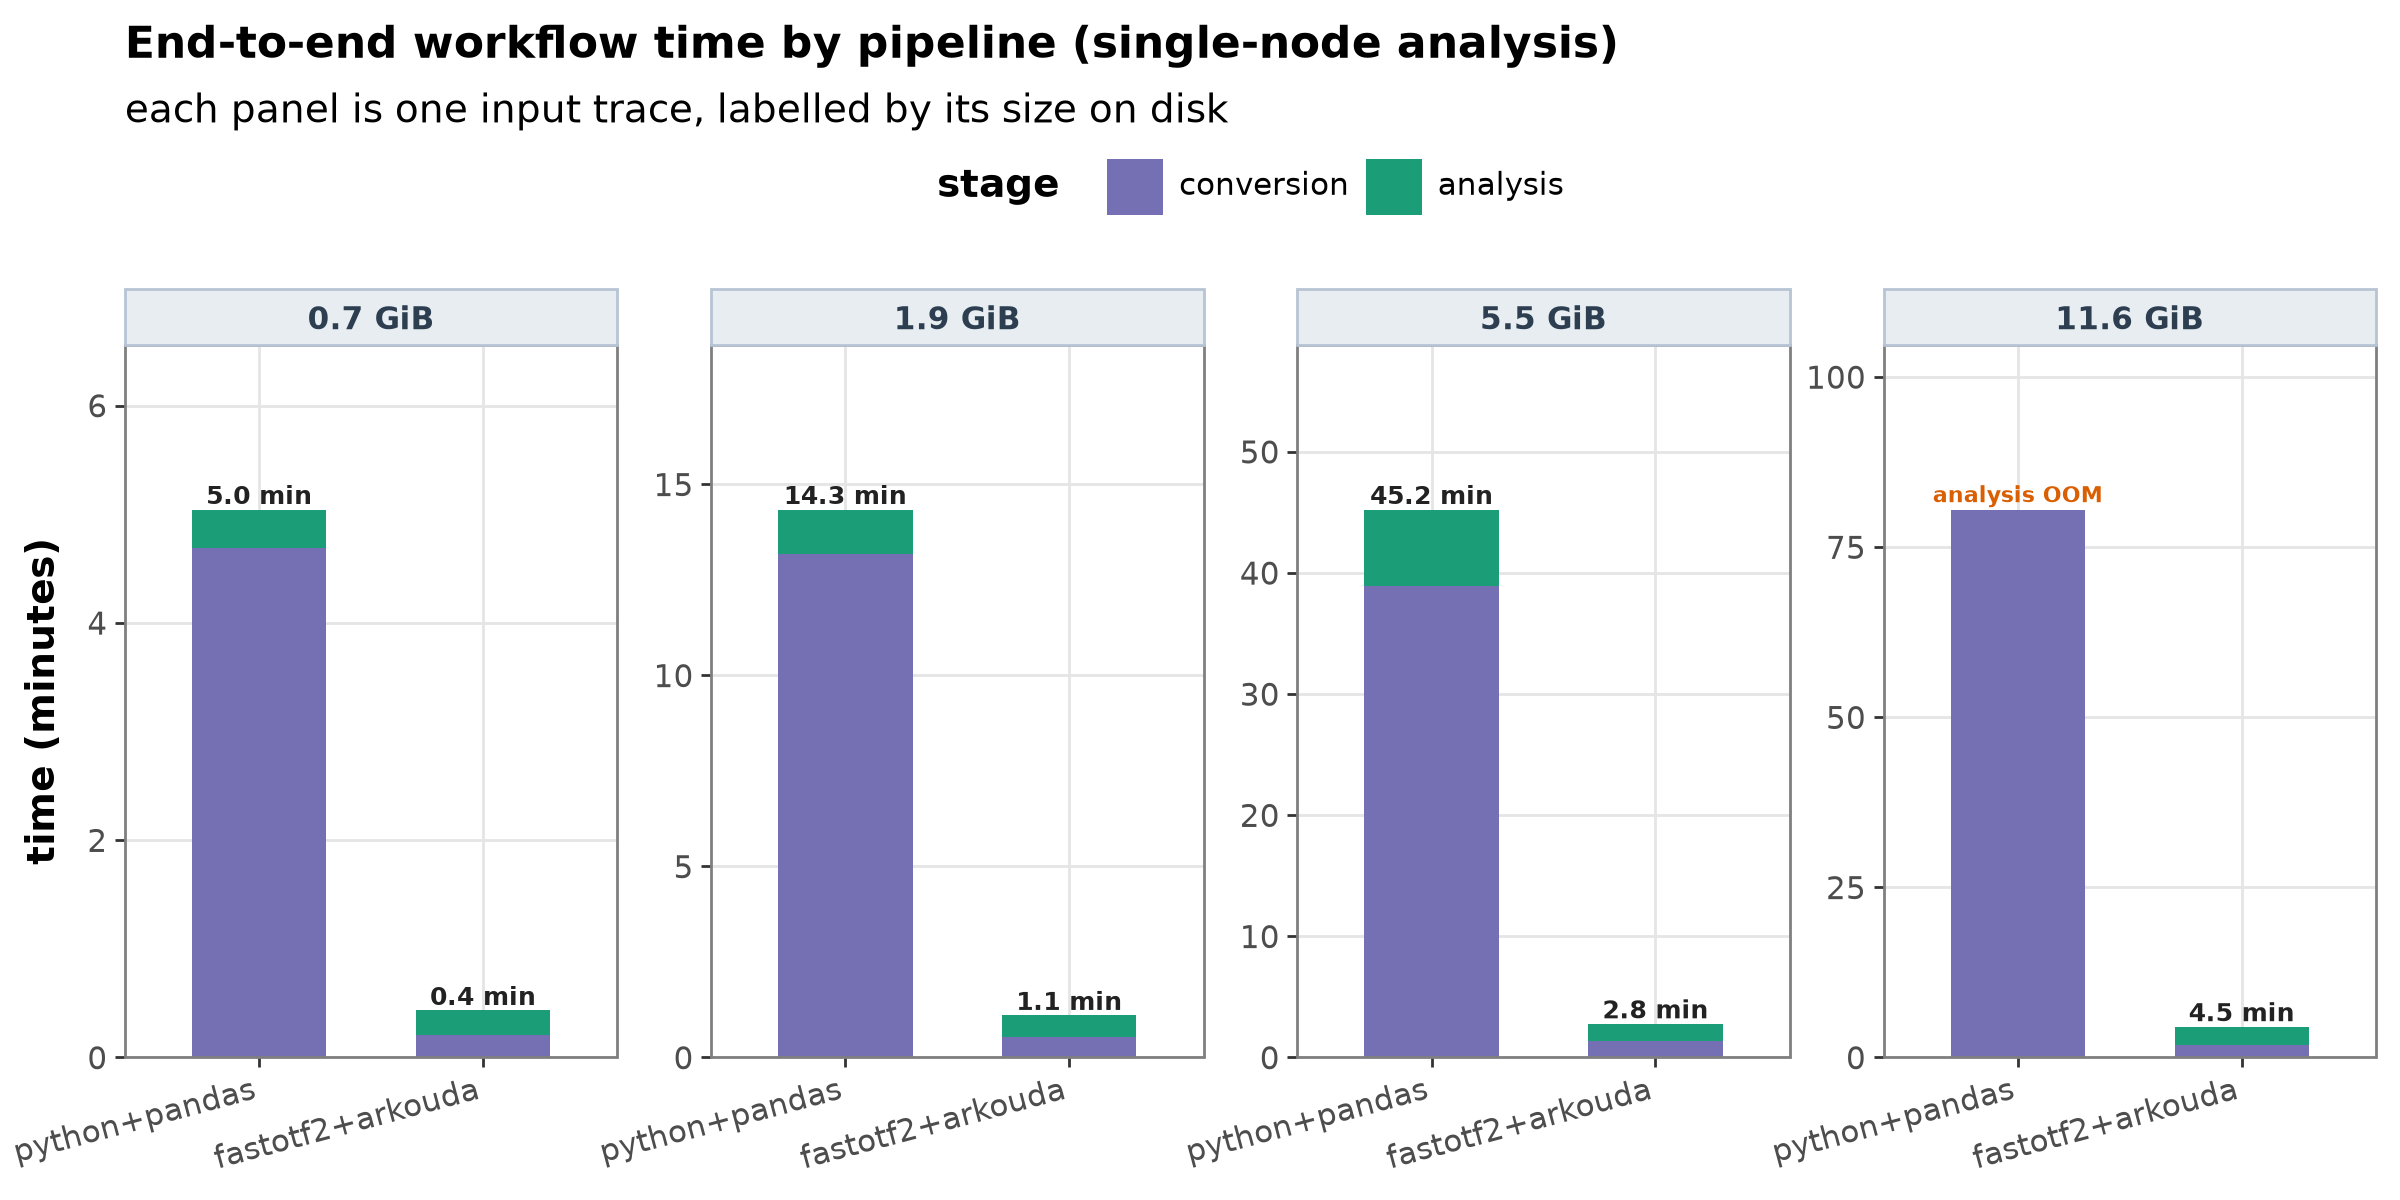

In [27]:
# Graph 1 — end-to-end workflow time by pipeline (single-node analysis): conversion + analysis.
# Head-to-head only: traces where BOTH pipelines were attempted (a pandas row exists, ok or OOM).
# Arkouda is shown at its FEWEST nodes so it lines up with single-node pandas; multi-node arkouda
# scaling is Graph 3, and the big arkouda-only traces are Graph 5.
_pandas_sizes = set(res.loc[res["backend"] == "pandas", "size_gib"])
_h2h = res[res["size_gib"].isin(_pandas_sizes)].copy()
_ark = (_h2h[_h2h["backend"] == "arkouda"].sort_values("analysis_nodes")
        .groupby("trace", as_index=False, observed=True).first())
_pan = _h2h[_h2h["backend"] == "pandas"]
_g1 = pd.concat([_pan, _ark], ignore_index=True)

_long = _g1.melt(id_vars=["trace", "pipeline", "backend", "status"],
                 value_vars=["conversion_min", "analysis_min"],
                 var_name="stage", value_name="minutes")
_long["stage"] = pd.Categorical(
    _long["stage"].map({"conversion_min": "conversion", "analysis_min": "analysis"}),
    categories=["conversion", "analysis"], ordered=True)
_bars = _long.dropna(subset=["minutes"])

# Total minutes labelled on each bar so the differing per-panel y-axes can't be misread; the
# pandas OOM bar (analysis never ran) gets an explicit "analysis OOM" flag instead of a total.
_oom1 = _g1[_g1["status"].eq("oom")].copy()
_oom_keys = set(zip(_oom1["trace"].astype(str), _oom1["pipeline"].astype(str)))
_tot = _bars.groupby(["trace", "pipeline"], observed=True)["minutes"].sum().reset_index()
_tot = _tot[~_tot.apply(lambda r: (str(r["trace"]), str(r["pipeline"])) in _oom_keys, axis=1)].copy()
_tot["lbl"] = _tot["minutes"].map(lambda v: f"{v:.1f} min")

# position_stack(reverse=True) -> conversion (step 1) on the BOTTOM, analysis on top.
g1 = (ggplot(_bars, aes("pipeline", "minutes", fill="stage"))
      + geom_col(width=0.6, position=position_stack(reverse=True))
      + geom_text(_tot, aes("pipeline", "minutes", label="lbl"), inherit_aes=False,
                  va="bottom", size=9, color="#222222", fontweight="bold")
      + facet_wrap("~trace", scales="free_y", ncol=4)
      + scale_fill_manual(values=STAGE_COLORS, name="stage", breaks=["conversion", "analysis"])
      + scale_y_continuous(expand=(0, 0, 0.30, 0))
      + labs(title="End-to-end workflow time by pipeline (single-node analysis)",
             subtitle="each panel is one input trace, labelled by its size on disk",
             x="", y="time (minutes)")
      + theme_pub(12, 6)
      + theme(axis_text_x=element_text(rotation=15, ha="right")))

if len(_oom1):
    _oom1 = _oom1.assign(y=_oom1["conversion_min"].fillna(0.0), lbl="analysis OOM")
    g1 = g1 + geom_text(_oom1, aes("pipeline", "y", label="lbl"), inherit_aes=False,
                        color=_OOM_COLOR, va="bottom", size=8, fontweight="bold")
_save(g1, "g1_end_to_end_stacked")
g1

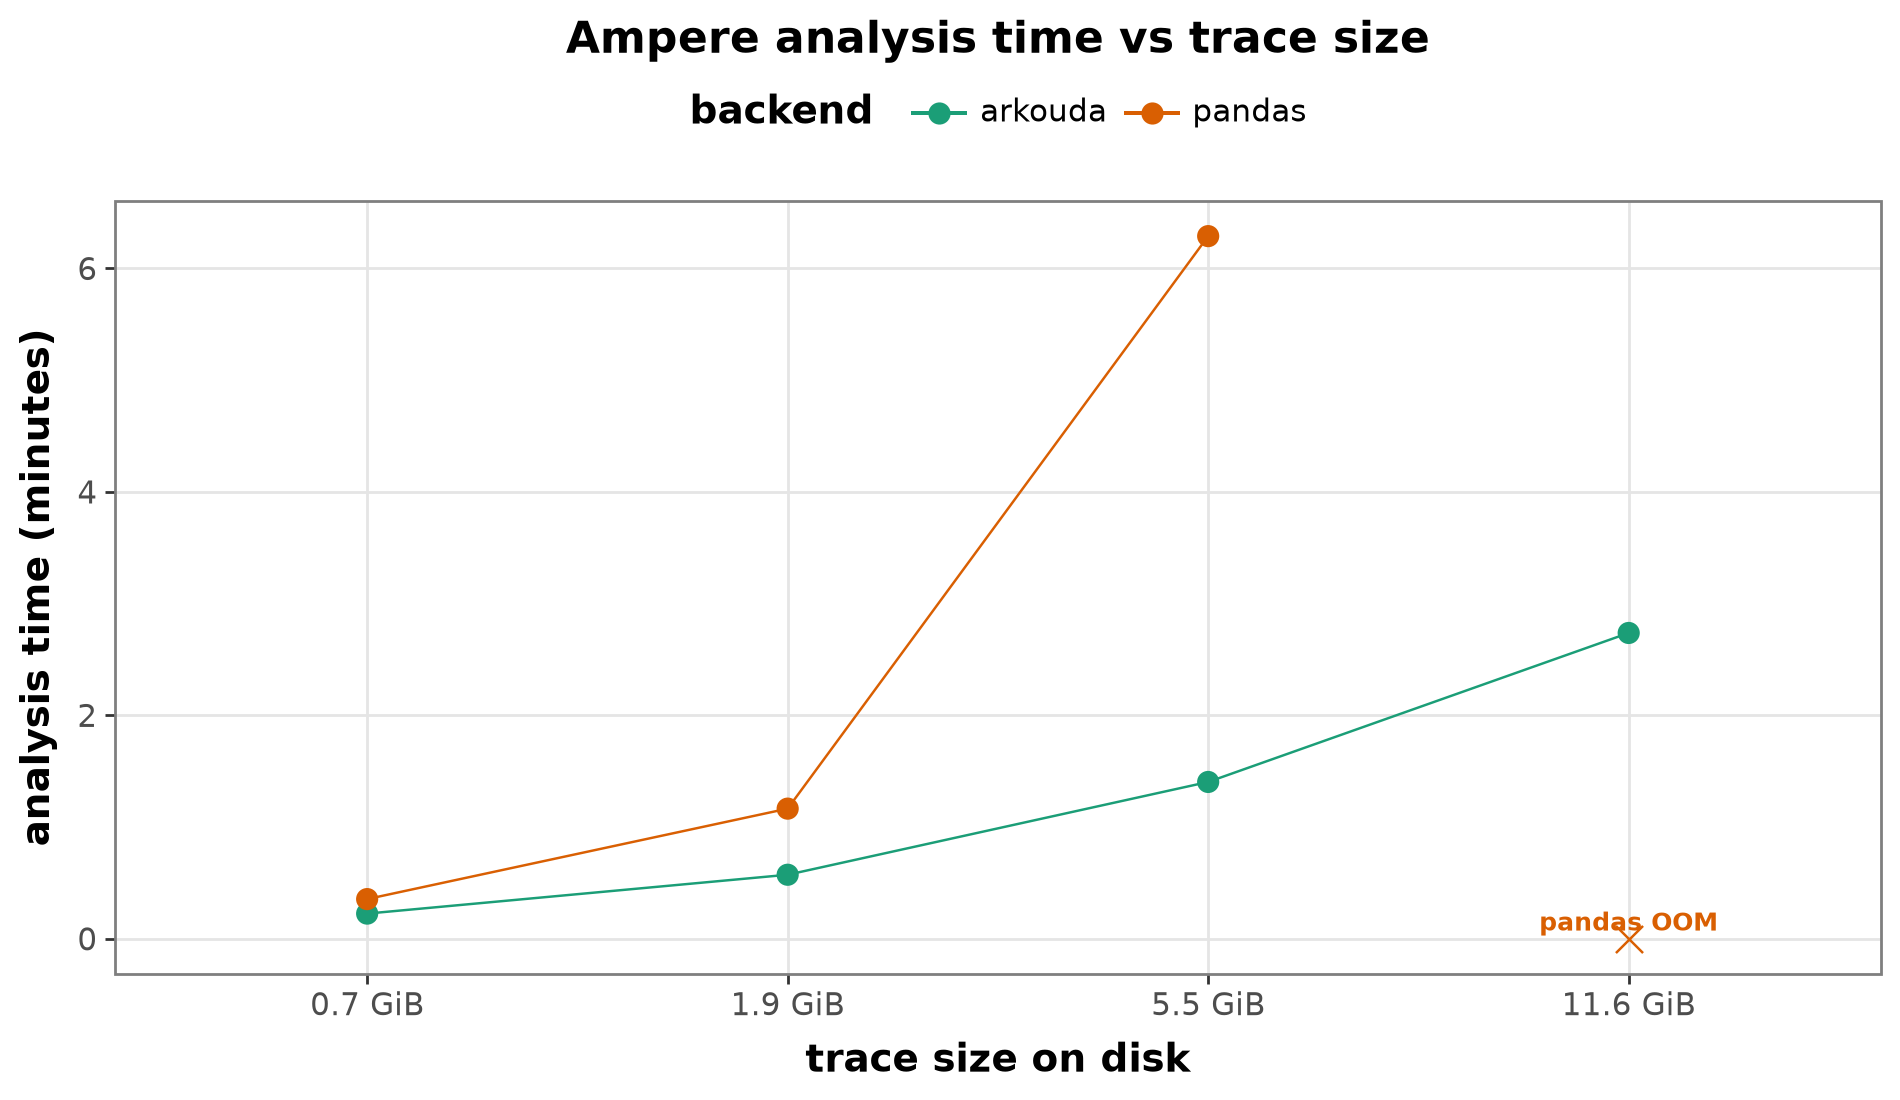

In [28]:
# Graph 2 — analysis time vs trace size (both backends), MINUTES on a LINEAR axis.
_g2 = res[res["analysis_min"].notna()].copy()
_g2["series"] = _g2["backend"] + " @" + _g2["analysis_nodes"].astype(str) + "n"
_multi = _g2["analysis_nodes"].nunique() > 1   # only distinguish node counts if >1 is present

# shape encodes analysis-node count ONLY when several are plotted together (e.g. arkouda 16@1 vs
# 16@4); with a single node count it would be a redundant one-item legend, so we drop it.
_aes = (aes("trace", "analysis_min", color="backend", shape="factor(analysis_nodes)", group="series")
        if _multi else aes("trace", "analysis_min", color="backend", group="series"))
g2 = (ggplot(_g2, _aes)
      + geom_line()
      + geom_point(size=3.5)
      + scale_color_manual(values=BACKEND_COLORS, name="backend")
      + labs(title="Ampere analysis time vs trace size",
             x="trace size on disk", y="analysis time (minutes)")
      + expand_limits(y=0)
      + theme_pub(9.5, 5.5))
if _multi:
    g2 = g2 + scale_shape_discrete(name="analysis nodes")

# Mark known pandas OOMs (no analysis time) at the baseline so the failure reads explicitly.
_oom = res[res["status"].eq("oom")].copy()
if len(_oom):
    _oom["analysis_min"] = 0.0
    _oom["lbl"] = "pandas OOM"
    g2 = (g2
          + geom_point(_oom, aes("trace", "analysis_min"), color=_OOM_COLOR,
                       shape="x", size=5, inherit_aes=False)
          + geom_text(_oom, aes("trace", "analysis_min", label="lbl"), color=_OOM_COLOR,
                      va="bottom", size=9, fontweight="bold", inherit_aes=False))
_save(g2, "g2_analysis_vs_size")
g2

In [29]:
# Graph 3 — arkouda analysis strong scaling: analysis time (min) vs server node count.
_ark = res[(res["backend"] == "arkouda") & res["analysis_min"].notna()].copy()
if _ark["analysis_nodes"].nunique() > 1:
    _ns = sorted(_ark["analysis_nodes"].unique())
    g3 = (ggplot(_ark, aes("analysis_nodes", "analysis_min", color="trace", group="trace"))
          + geom_line() + geom_point(size=3.5)
          + scale_x_continuous(trans="log2", breaks=_ns, labels=[str(n) for n in _ns])
          + scale_color_brewer(type="qual", palette="Dark2", name="trace size")
          + labs(title="Arkouda analysis strong scaling",
                 subtitle="fixed trace, more server nodes (lower is better)",
                 x="arkouda server nodes (log2 spacing)", y="analysis time (minutes)")
          + expand_limits(y=0)
          + theme_pub(9.5, 5.5))
    _save(g3, "g3_arkouda_strong_scaling")
    display(g3)
else:
    print("Strong-scaling graph needs >= 2 analysis-node counts for a trace "
          "(only single-node arkouda results are present so far).")


Strong-scaling graph needs >= 2 analysis-node counts for a trace (only single-node arkouda results are present so far).


,trace,e2e_pandas,e2e_arkouda,arkouda_nodes,speedup
0,0.7 GiB,5.04,0.43,1,11.67
1,1.9 GiB,14.34,1.10,1,13.04
2,5.5 GiB,45.23,2.78,1,16.28


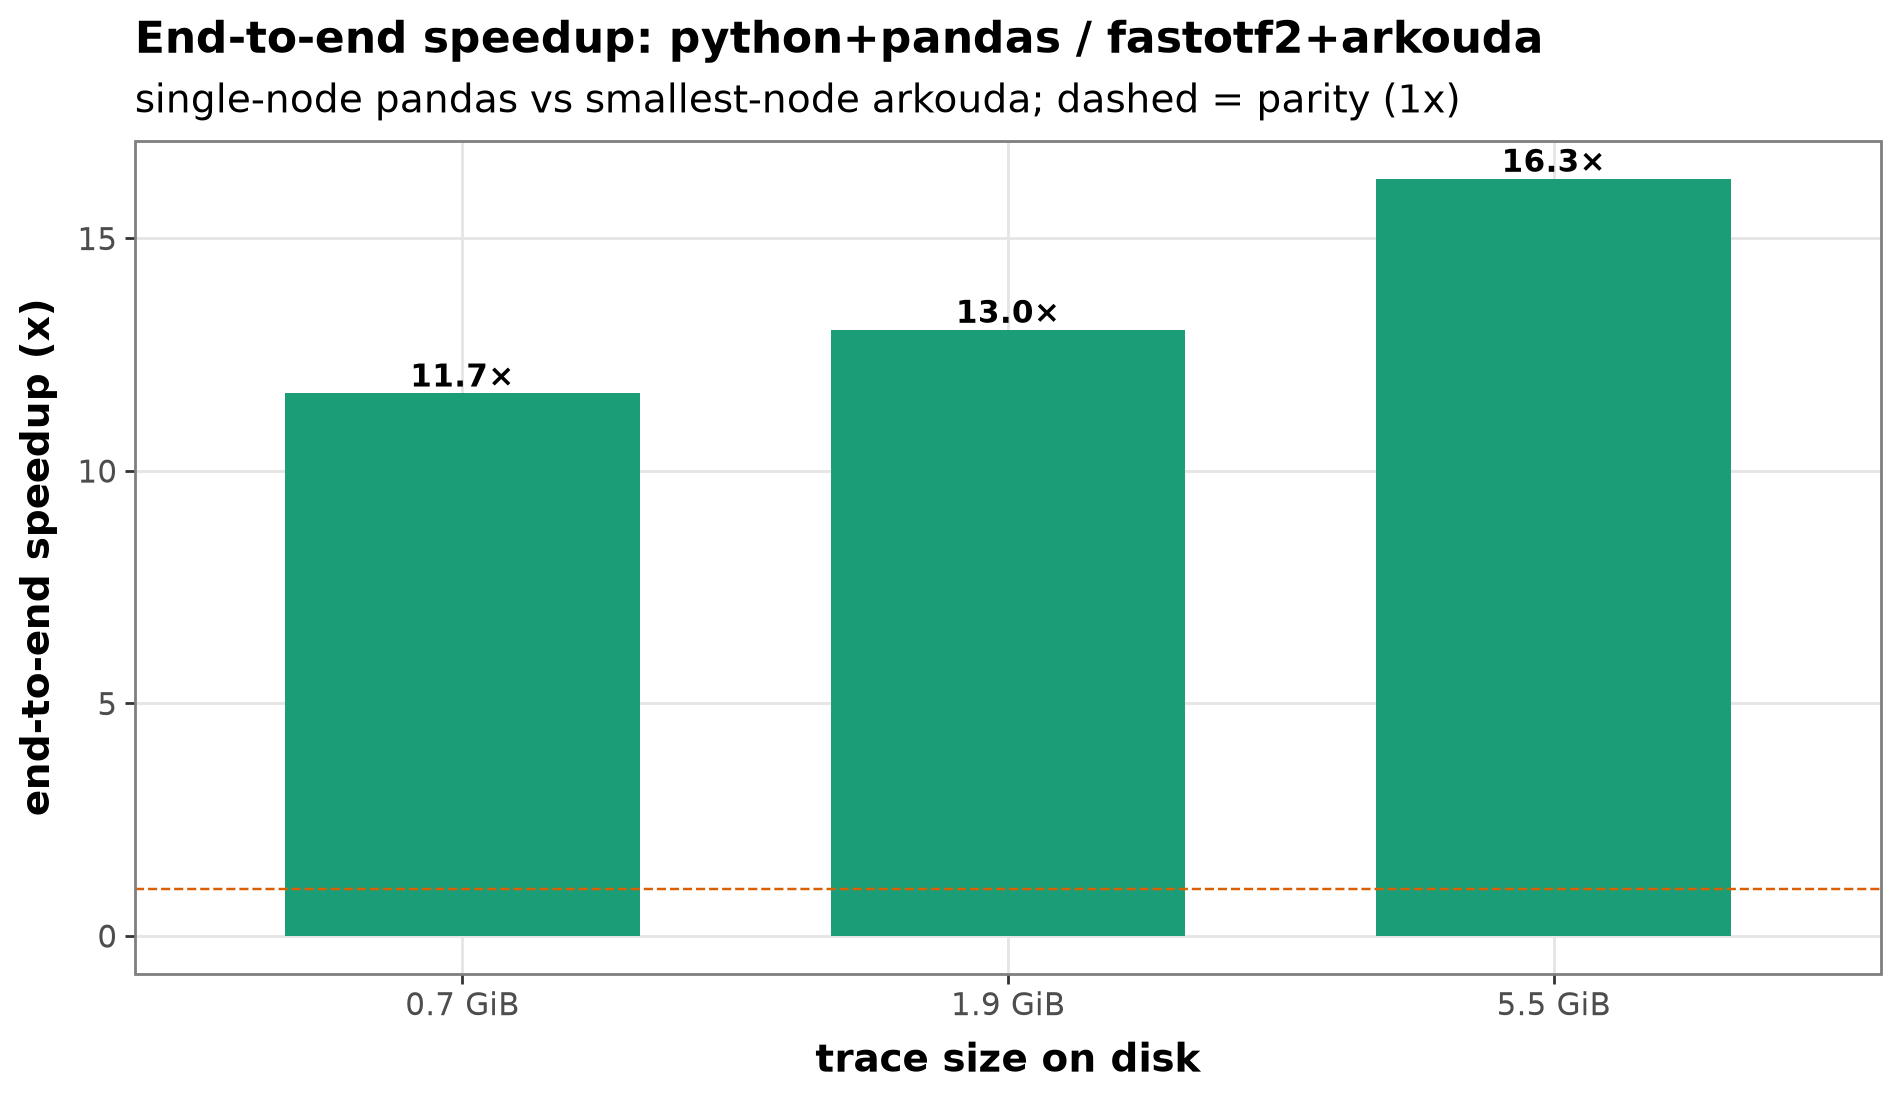

In [30]:
# Graph 4 — end-to-end speedup (python+pandas / fastotf2+arkouda) on the head-to-head traces.
# Like-for-like single node: pandas@1 vs arkouda@smallest-node-count.
_pan = (res[res["backend"] == "pandas"]
        .rename(columns={"end_to_end_min": "e2e_pandas"})
        [["trace", "size_gib", "e2e_pandas", "status"]])
_arkbase = (res[res["backend"] == "arkouda"].sort_values("analysis_nodes")
            .groupby("trace", as_index=False, observed=True).first()
            .rename(columns={"end_to_end_min": "e2e_arkouda", "analysis_nodes": "arkouda_nodes"})
            [["trace", "e2e_arkouda", "arkouda_nodes"]])
_spd = _pan.merge(_arkbase, on="trace", how="inner")
_spd = _spd[_spd["status"].ne("oom") & _spd["e2e_pandas"].notna()
            & _spd["e2e_arkouda"].notna()].copy()

if len(_spd):
    _spd["speedup"] = _spd["e2e_pandas"] / _spd["e2e_arkouda"]
    _spd["lbl"] = _spd["speedup"].map(lambda v: f"{v:.1f}×")
    display(_spd[["trace", "e2e_pandas", "e2e_arkouda", "arkouda_nodes", "speedup"]].round(2))
    g4 = (ggplot(_spd, aes("trace", "speedup"))
          + geom_col(fill=BACKEND_COLORS["arkouda"], width=0.65)
          + geom_text(aes(label="lbl"), va="bottom", size=11, fontweight="bold", format_string="")
          + geom_hline(yintercept=1.0, linetype="dashed", color=_OOM_COLOR)
          + expand_limits(y=0)
          + labs(title="End-to-end speedup: python+pandas / fastotf2+arkouda",
                 subtitle="single-node pandas vs smallest-node arkouda; dashed = parity (1x)",
                 x="trace size on disk", y="end-to-end speedup (x)")
          + theme_pub(9.5, 5.5))
    _save(g4, "g4_end_to_end_speedup")
    display(g4)
else:
    print("No head-to-head traces with BOTH a pandas and an arkouda result yet.")


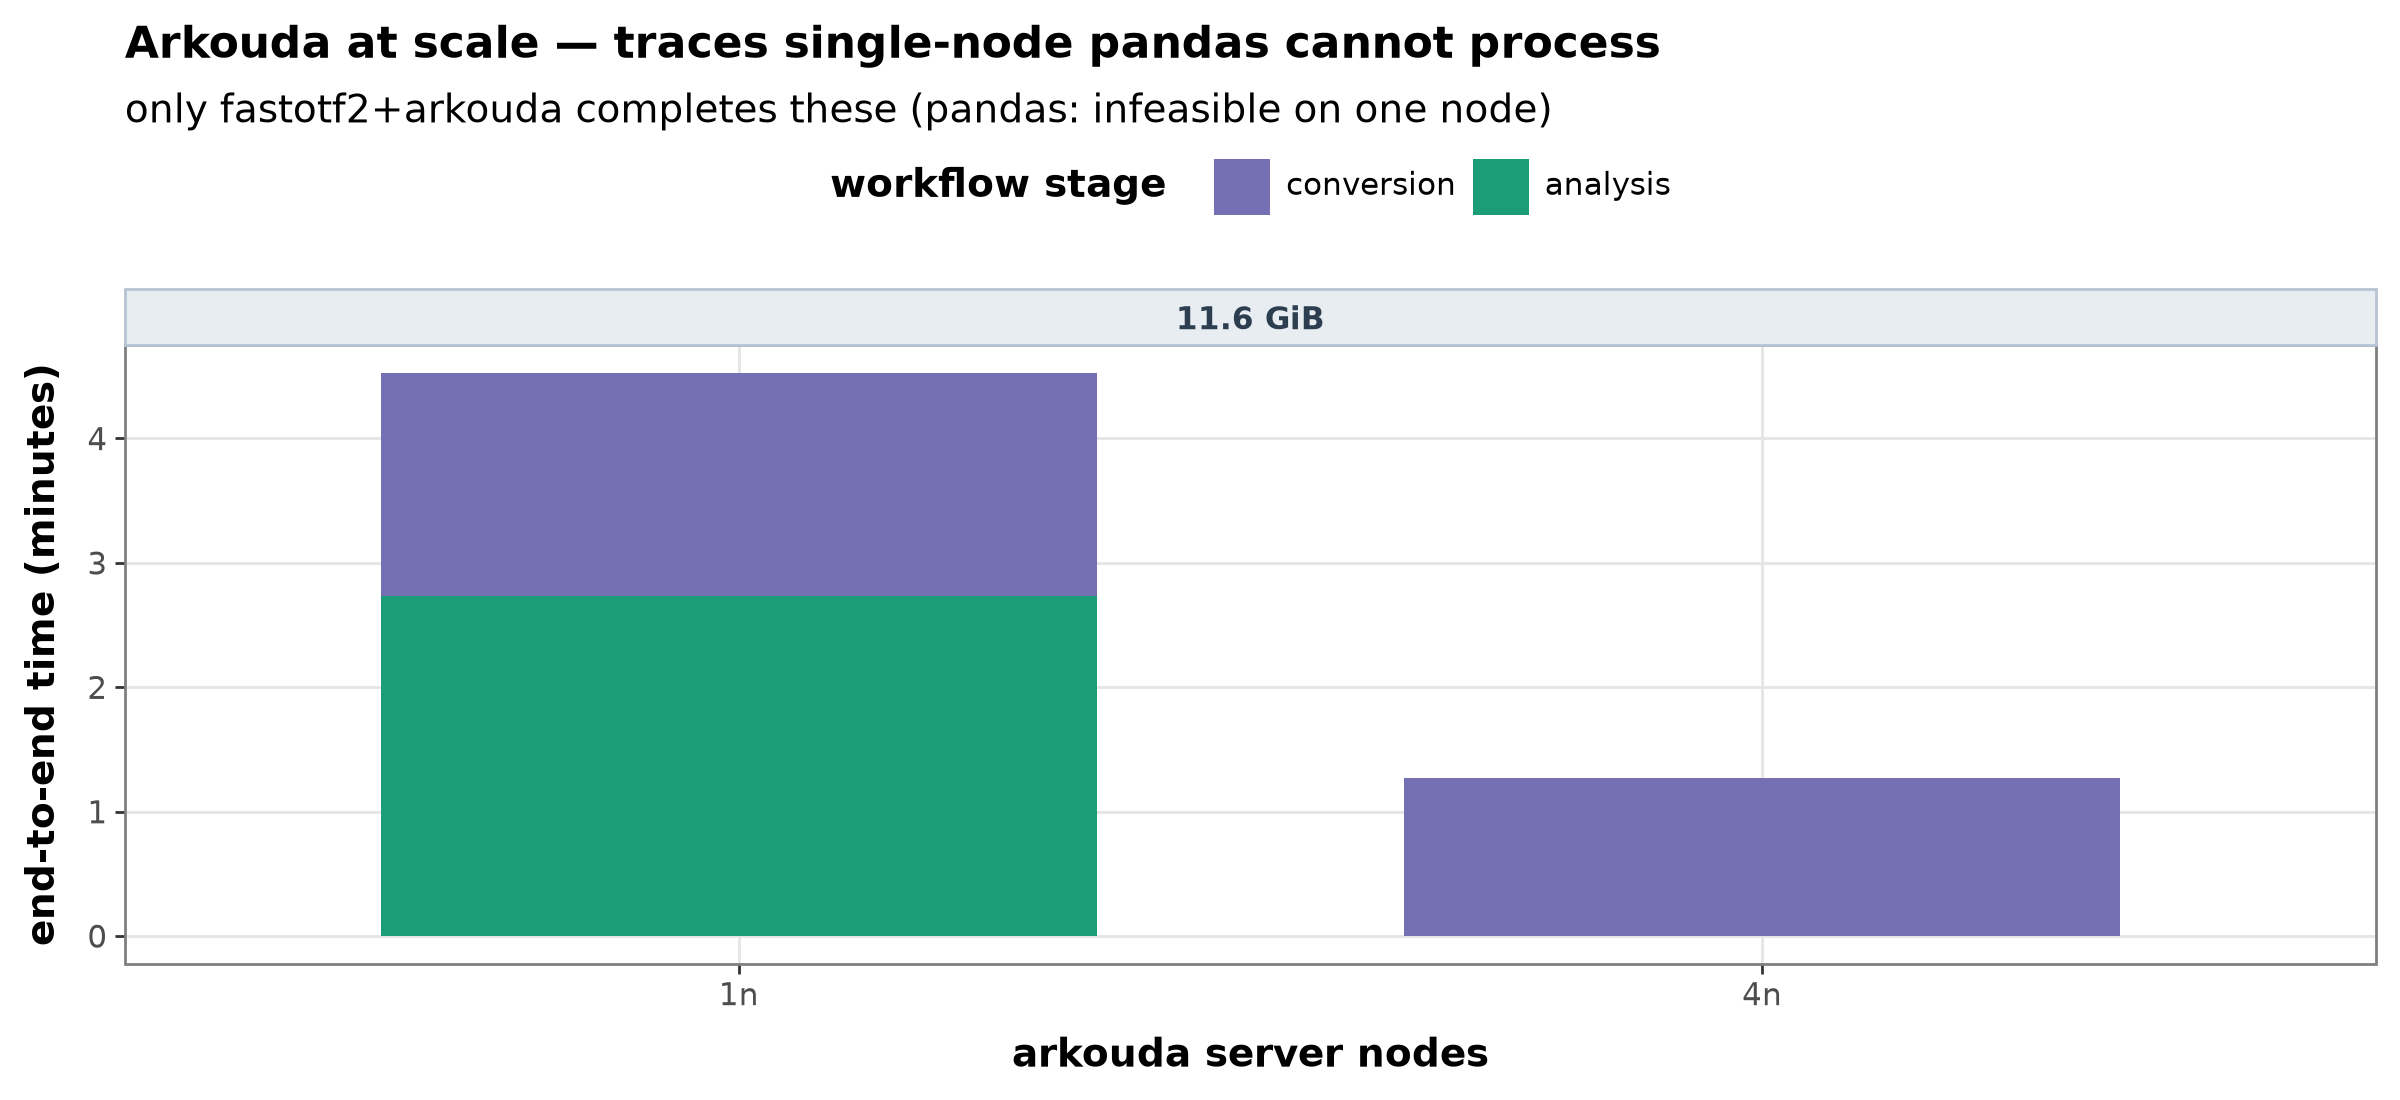

In [31]:
# Graph 5 — arkouda-only at scale: the largest traces single-node pandas cannot process.
_arkonly_sizes = sorted(set(res.loc[res["backend"] == "arkouda", "size_gib"])
                        - set(res.loc[(res["backend"] == "pandas") & res["status"].ne("oom"),
                                      "size_gib"]))
_arkonly = res[(res["backend"] == "arkouda") & res["size_gib"].isin(_arkonly_sizes)].copy()

if len(_arkonly):
    _arkonly["config"] = _arkonly["analysis_nodes"].astype(str) + "n"
    _al = _arkonly.melt(id_vars=["trace", "config"],
                        value_vars=["conversion_min", "analysis_min"],
                        var_name="stage", value_name="minutes")
    _al["stage"] = pd.Categorical(
        _al["stage"].map({"conversion_min": "conversion", "analysis_min": "analysis"}),
        categories=["conversion", "analysis"], ordered=True)
    g5 = (ggplot(_al.dropna(subset=["minutes"]), aes("config", "minutes", fill="stage"))
          + geom_col(width=0.7)
          + facet_wrap("~trace", scales="free", ncol=4)
          + scale_fill_manual(values=STAGE_COLORS, name="workflow stage")
          + labs(title="Arkouda at scale — traces single-node pandas cannot process",
                 subtitle="only fastotf2+arkouda completes these (pandas: infeasible on one node)",
                 x="arkouda server nodes", y="end-to-end time (minutes)")
          + expand_limits(y=0)
          + theme_pub(12, 5.5))
    _save(g5, "g5_arkouda_only_at_scale")
    display(g5)
else:
    print("No arkouda-only traces in this run (all sizes also have a pandas result).")
